<br>

<h1 style="text-align:center;">Emotion Classification</h1>
<h3 style="text-align:center;">using BERT</h3>

<br>

# Project Overview

---

This project implements a sophisticated multi-task learning system using BERT for emotion classification using television show transcripts. Our approach simultaneously analyzes three key dimensions of emotional expression:O

1. **Primary Emotions:**  Happiness, Sadness, Anger, Fear, Disgust, Surprise, Neutral
2. **Secondary Emotions:** Fine-grained emotional states (e.g., Curiosity, Pride, etc.)
3. **Emotional Intensity:** Mild, Moderate, Neutral, Intense, verwhelming

### Table of Contents

1. [Initial Setup](#initial-setup)
2. [Load Data](#load-dataset)
3. [Data Quality Assessment](#data-quality-assessment)
4. [Iteration 1](#iteration-1)
5. [Iteration 2](#iteration-2)
6. [Iteration 3](#iteration-3)
7. [Iteration 4](#iteration-4)
8. [Model Iteration Summary](#model-iteration-summary)

<br>

# Initial Setup

---

Import necessary libraries and configure environment settings.

In [3]:
# Import helper module
import helper
from helper.data import *
from helper.train import *
from helper.error_analysis import *
from helper.predict import *

c:\Users\Soheil\.conda\envs\llm\lib\site-packages\huggingface_hub\utils\_deprecation.py:131: FutureWarning: '__init_subclass__' (from 'transformers.agents.tools') is deprecated and will be removed from version '4.51.0'. Switch to smolagents instead, with the same functionalities and similar API (https://huggingface.co/docs/smolagents/index)
  warnings.warn(warning_message, FutureWarning)


In [4]:
# Import the libraries
import os
import warnings
import numpy as np
import pandas as pd
import pickle
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn import functional as F
from transformers import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import nltk
from tqdm import tqdm
import torch
import torch.nn as nn
import joblib
import numpy as np

In [5]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [6]:
# Matplotlib style
plt.style.use('ggplot')

In [7]:
# Turn off warnings
warnings.filterwarnings('ignore')

In [8]:
# Download necessary NLTK resources
nltk.download('all', quiet=True)

True

<br>

# Load Dataset

---

Load and clean emotion-labeled text data.


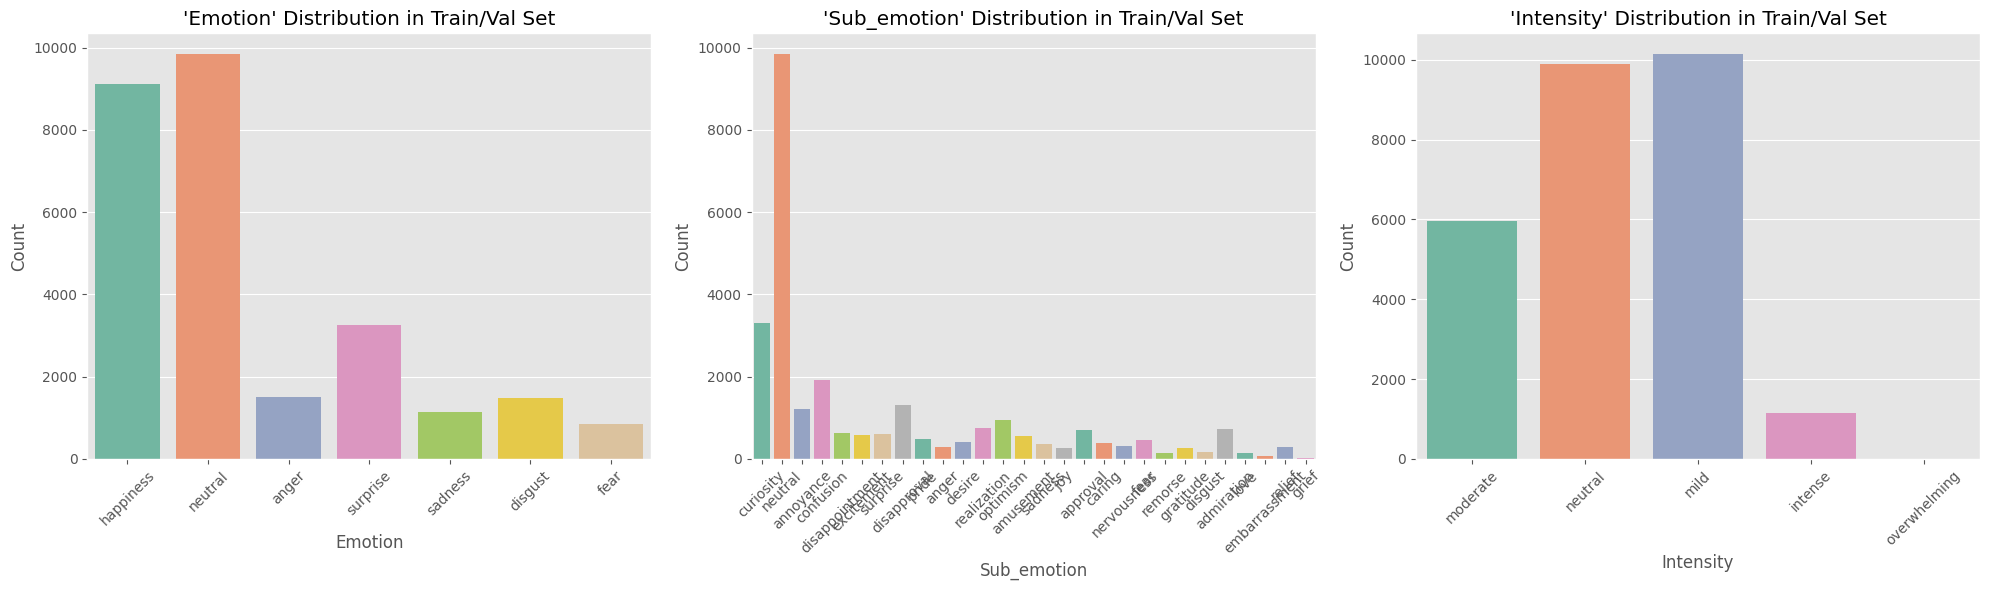

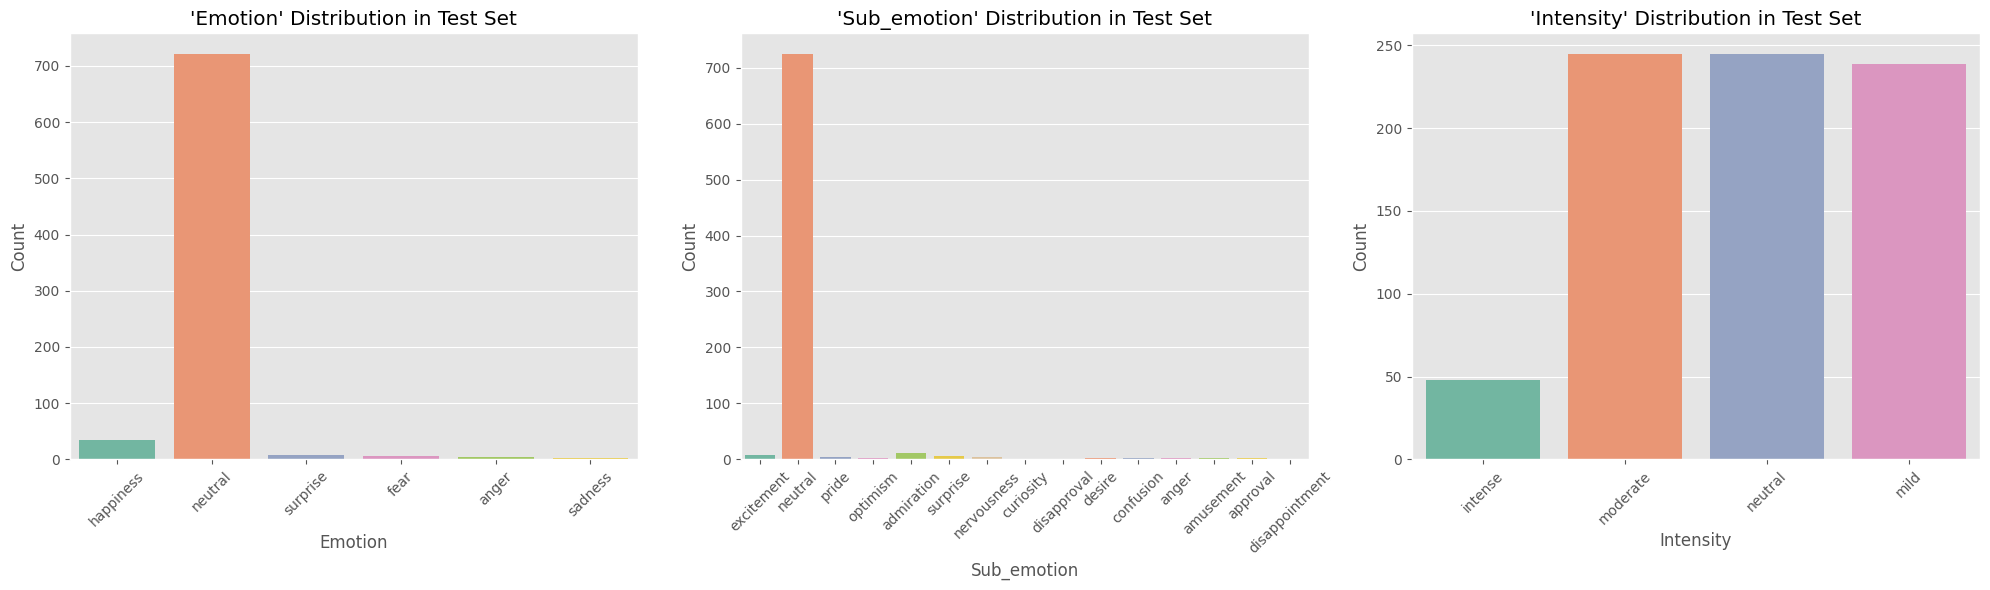

In [9]:
# Initialize the data loader
data_loader = DatasetLoader()

# Load training/validation data
df = data_loader.load_training_data()

# Load test data
test_df = data_loader.load_test_data()

# Plot distributions
data_loader.plot_distributions()

<br>

# Data Quality Assessment

---


In this section, we will evaluate the quality and suitability of the dataset used in this project. This includes identifying potential imbalances, biases, or limitations within the data. Based on the findings, we will propose appropriate adjustments or provide justifications to ensure the dataset aligns with the objectives of the emotion classification task.

In [8]:
# Initialize the assessor
assessor = DataQualityAssessor(df)

### 1. Assess Class Imbalance

The dataset shows significant class imbalance with neutral and happiness emotions dominating (69.77% combined) while fear, sadness, and disgust are underrepresented (12.76% combined). The imbalance ratio of 11.52:1 between majority (neutral) and minority (fear) classes indicates a severe imbalance that could lead to biased model predictions, particularly for minority emotions.


Class distribution:
neutral: 9858 samples (36.26%)
happiness: 9109 samples (33.51%)
surprise: 3254 samples (11.97%)
anger: 1495 samples (5.50%)
disgust: 1473 samples (5.42%)
sadness: 1140 samples (4.19%)
fear: 856 samples (3.15%)

Imbalance ratio (majority:minority): 11.52:1


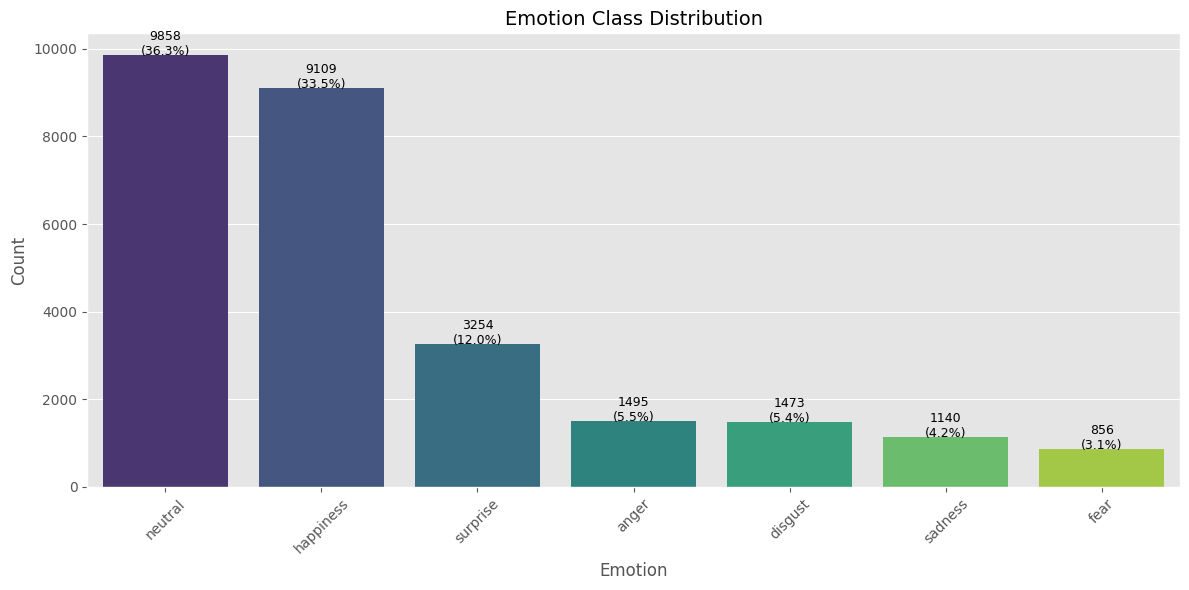

(emotion
 neutral      9858
 happiness    9109
 surprise     3254
 anger        1495
 disgust      1473
 sadness      1140
 fear          856
 Name: count, dtype: int64,
 11.516355140186915)

In [9]:
assessor.assess_class_imbalance()

### 2. Address Class Imbalance

The computed class weights effectively address the imbalance by assigning higher weights to minority classes. For instance, fear (class 6) gets a weight of 1.19 while surprise (class 2) gets 4.54, reflecting their relative scarcity. This weighting scheme will help the model pay more attention to minority classes during training, potentially improving their prediction accuracy.


In [10]:
class_weights_tensor = assessor.compute_class_weights()

print(class_weights_tensor)

Class weights: {0: 2.597706641184902, 1: 2.6365047037144795, 2: 4.536882510013351, 3: 0.42634443172372694, 4: 0.3939512506158885, 5: 3.406641604010025, 6: 1.1934761612081832}
tensor([2.5977, 2.6365, 4.5369, 0.4263, 0.3940, 3.4066, 1.1935],
       device='cuda:0')


### 3. Bias Analysis

1. **Text Length Bias**:
- Most emotions show similar median text lengths (31-37 characters)
- Neutral texts are notably shorter (median: 27 characters)
- Happiness shows the highest variability with extreme outliers up to 543 characters
- This length disparity could affect model performance across emotions

2. **Vocabulary Diversity**:
- Clear increasing trend in vocabulary diversity from happiness (19%) to fear (42%)
- Minority classes (fear, disgust) show higher vocabulary diversity (41-42%)
- Majority classes (happiness, neutral) show lower diversity (19-21%)
- This inverse relationship between class size and vocabulary diversity suggests potential sampling bias

3. **Sentiment Distribution**:
- Clear sentiment polarity alignment with emotions:
  * Happiness shows positive bias (mean: 0.146)
  * Negative emotions cluster around -0.03 to -0.05
  * Neutral and surprise show slight positive bias (0.047 and 0.022)
- Standard deviations indicate high sentiment variability within each emotion

4. **POS (Part of Speech) Distribution**:
- Personal pronouns (PRP) show consistent high usage (10-13%) across emotions
- Nouns (NN) usage varies significantly (8-10%)
- Verbs (VB, VBP) show emotion-specific patterns
- Adverbs (RB) are more prevalent in negative emotions
- These patterns suggest systematic linguistic differences between emotions

5. **Cultural/Contextual Patterns**:
- Personal pronouns usage is consistently high (8-9%) across all emotions
- Negation words show clear emotional patterns:
  * Higher in negative emotions (disgust: 5.05%, sadness: 4.42%)
  * Lower in positive emotions (happiness: 0.94%)
- Modal verbs and intensity modifiers show minimal variation
- These patterns suggest emotional-linguistic cultural biases

This bias analysis reveals systematic differences in how emotions are expressed in the dataset, which could impact model performance and generalization. The inverse relationship between class size and linguistic complexity (vocabulary diversity) is particularly noteworthy and should be considered during model development.


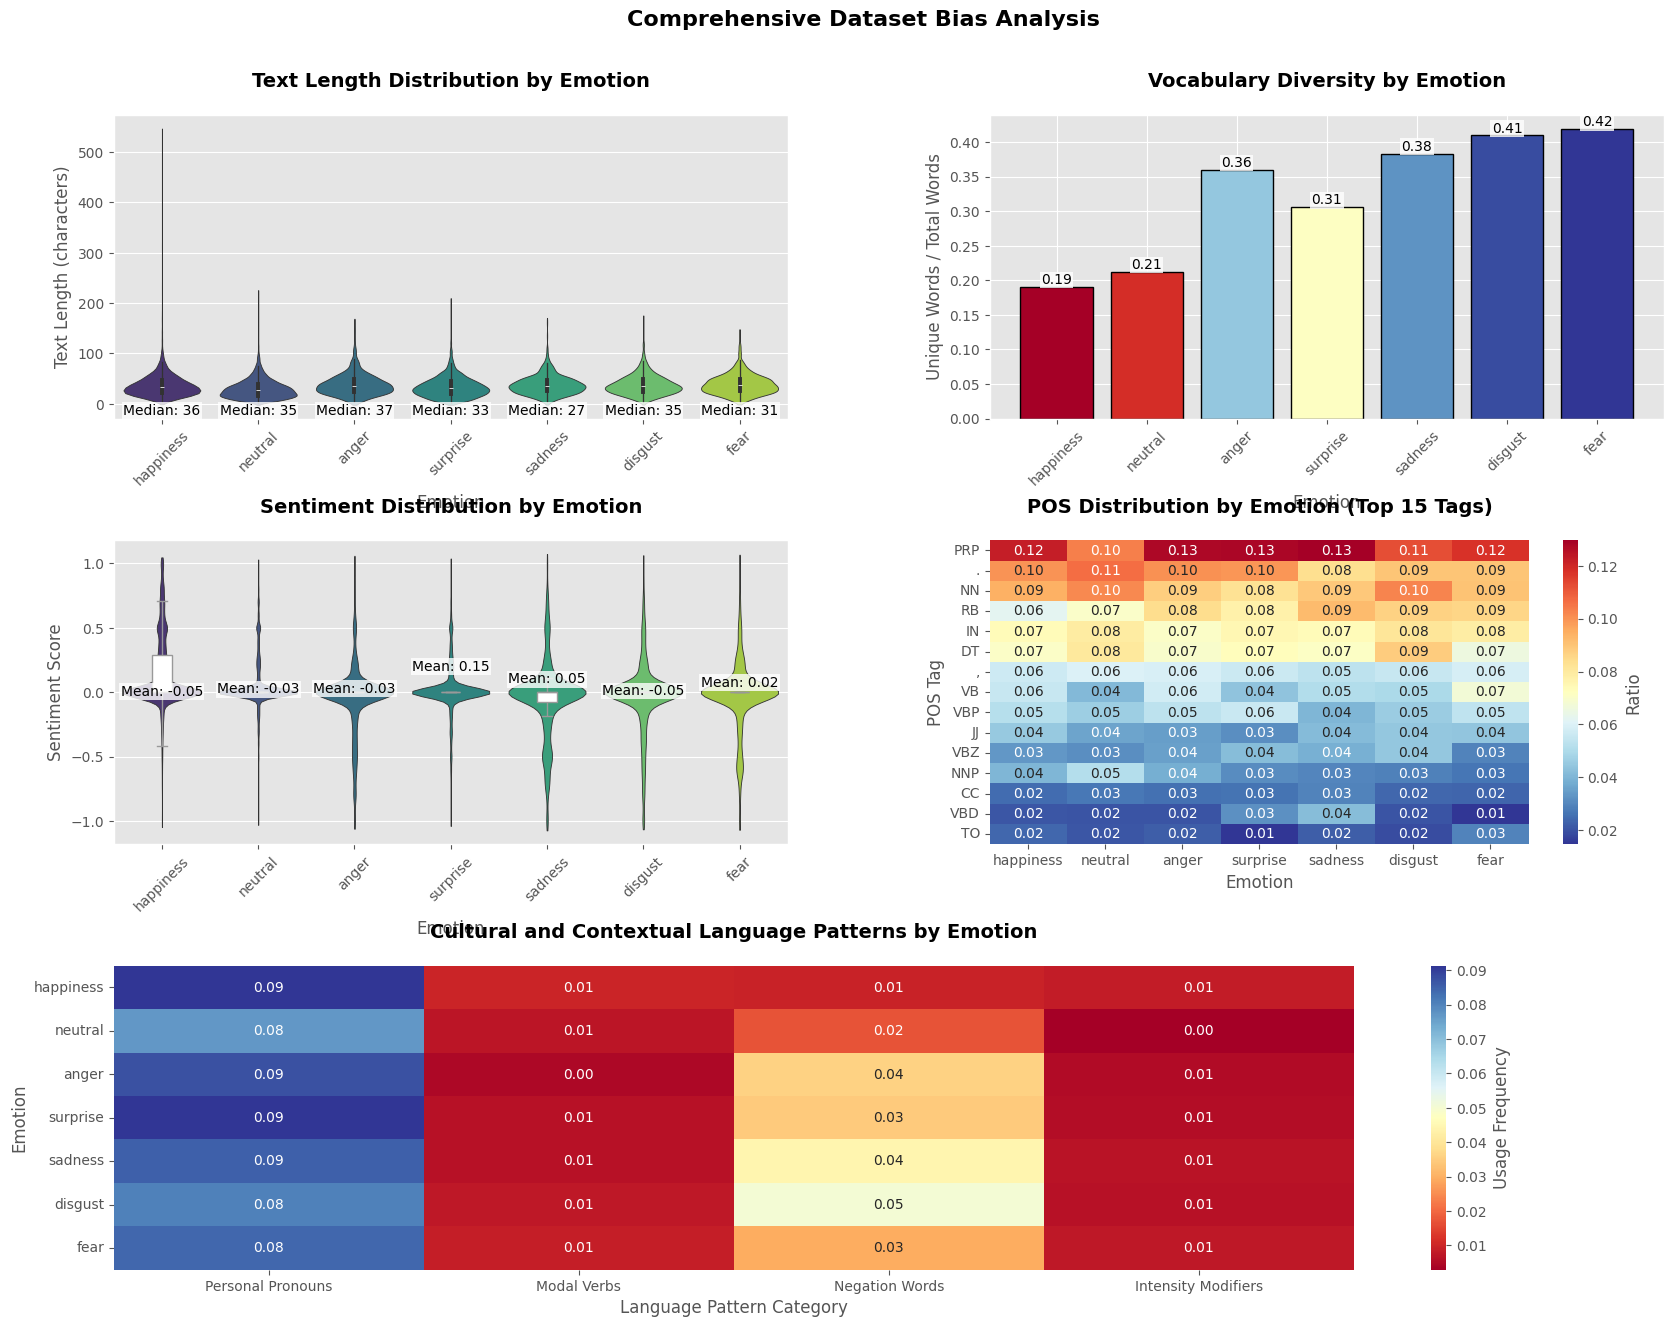


DATASET BIAS ANALYSIS REPORT

1. Text Length Bias:
            mean    std  min  max
emotion                          
anger      39.01  21.80    3  164
disgust    38.44  19.92    3  171
fear       39.52  20.32    4  143
happiness  37.19  24.21    3  543
neutral    30.26  18.89    1  223
sadness    38.32  19.35    3  166
surprise   34.08  20.47    2  206

2. Lexical Bias:

HAPPINESS:
  • Total words: 29,221
  • Unique words: 5,560
  • Vocabulary diversity: 19.03%
  • Most common words:
    - like: 443
    - think: 350
    - yes: 346
    - good: 339
    - want: 337

NEUTRAL:
  • Total words: 26,224
  • Unique words: 5,562
  • Vocabulary diversity: 21.21%
  • Most common words:
    - yes: 468
    - well: 306
    - one: 240
    - go: 229
    - know: 220

ANGER:
  • Total words: 4,880
  • Unique words: 1,754
  • Vocabulary diversity: 35.94%
  • Most common words:
    - yes: 67
    - ca: 51
    - want: 50
    - get: 49
    - stop: 49

SURPRISE:
  • Total words: 8,646
  • Unique words: 2,64

In [11]:
results = assessor.assess_bias()

### 4. Dataset Limitations Analysis

1. **Sub-emotion Coverage Imbalance**:
- Severe imbalance in sub-emotion distribution:
  * Happiness has 13 sub-emotions but highly skewed (curiosity: 12.2% vs love: 0.5%)
  * Neutral has only 1 sub-emotion (9,858 samples)
  * Other emotions have 2-4 sub-emotions with poor distribution
- Critical gaps in emotional granularity, especially for neutral emotion

2. **Intensity Distribution Issues**:
- Significant intensity bias across emotions:
  * Neutral is exclusively neutral intensity (100%)
  * Happiness and surprise dominated by mild intensity (≈70%)
  * Fear, anger, disgust show more balanced moderate-mild distribution
  * Overwhelming intensity is nearly absent (<0.3%) across all emotions
- Limited representation of intense emotional expressions

3. **Vocabulary and Text Length Limitations**:
- Vocabulary overlap matrix shows low similarity between emotions (15-35%)
- Significant vocabulary size disparity:
  * Major classes (happiness/neutral): ~5,500 words
  * Minor classes (fear/sadness): ~1,200-1,400 words
- Text length variations could impact model performance:
  * Mean lengths vary from 30 (neutral) to 40 (fear) words
  * High standard deviations (19-24 words) indicate inconsistent text lengths

4. **Dataset Balance Issues**:
- Severe class imbalance:
  * Dominant classes: neutral (9,858) and happiness (9,109)
  * Underrepresented classes: fear (856), sadness (1,140)
- Structural imbalances:
  * Sub-emotion count varies dramatically (1-13 per emotion)
  * Vocabulary size doesn't correlate with sample size
  * Average text length varies independently of emotion frequency

These limitations suggest potential challenges in model generalization and emotional nuance detection, particularly for underrepresented emotions and intensity levels.


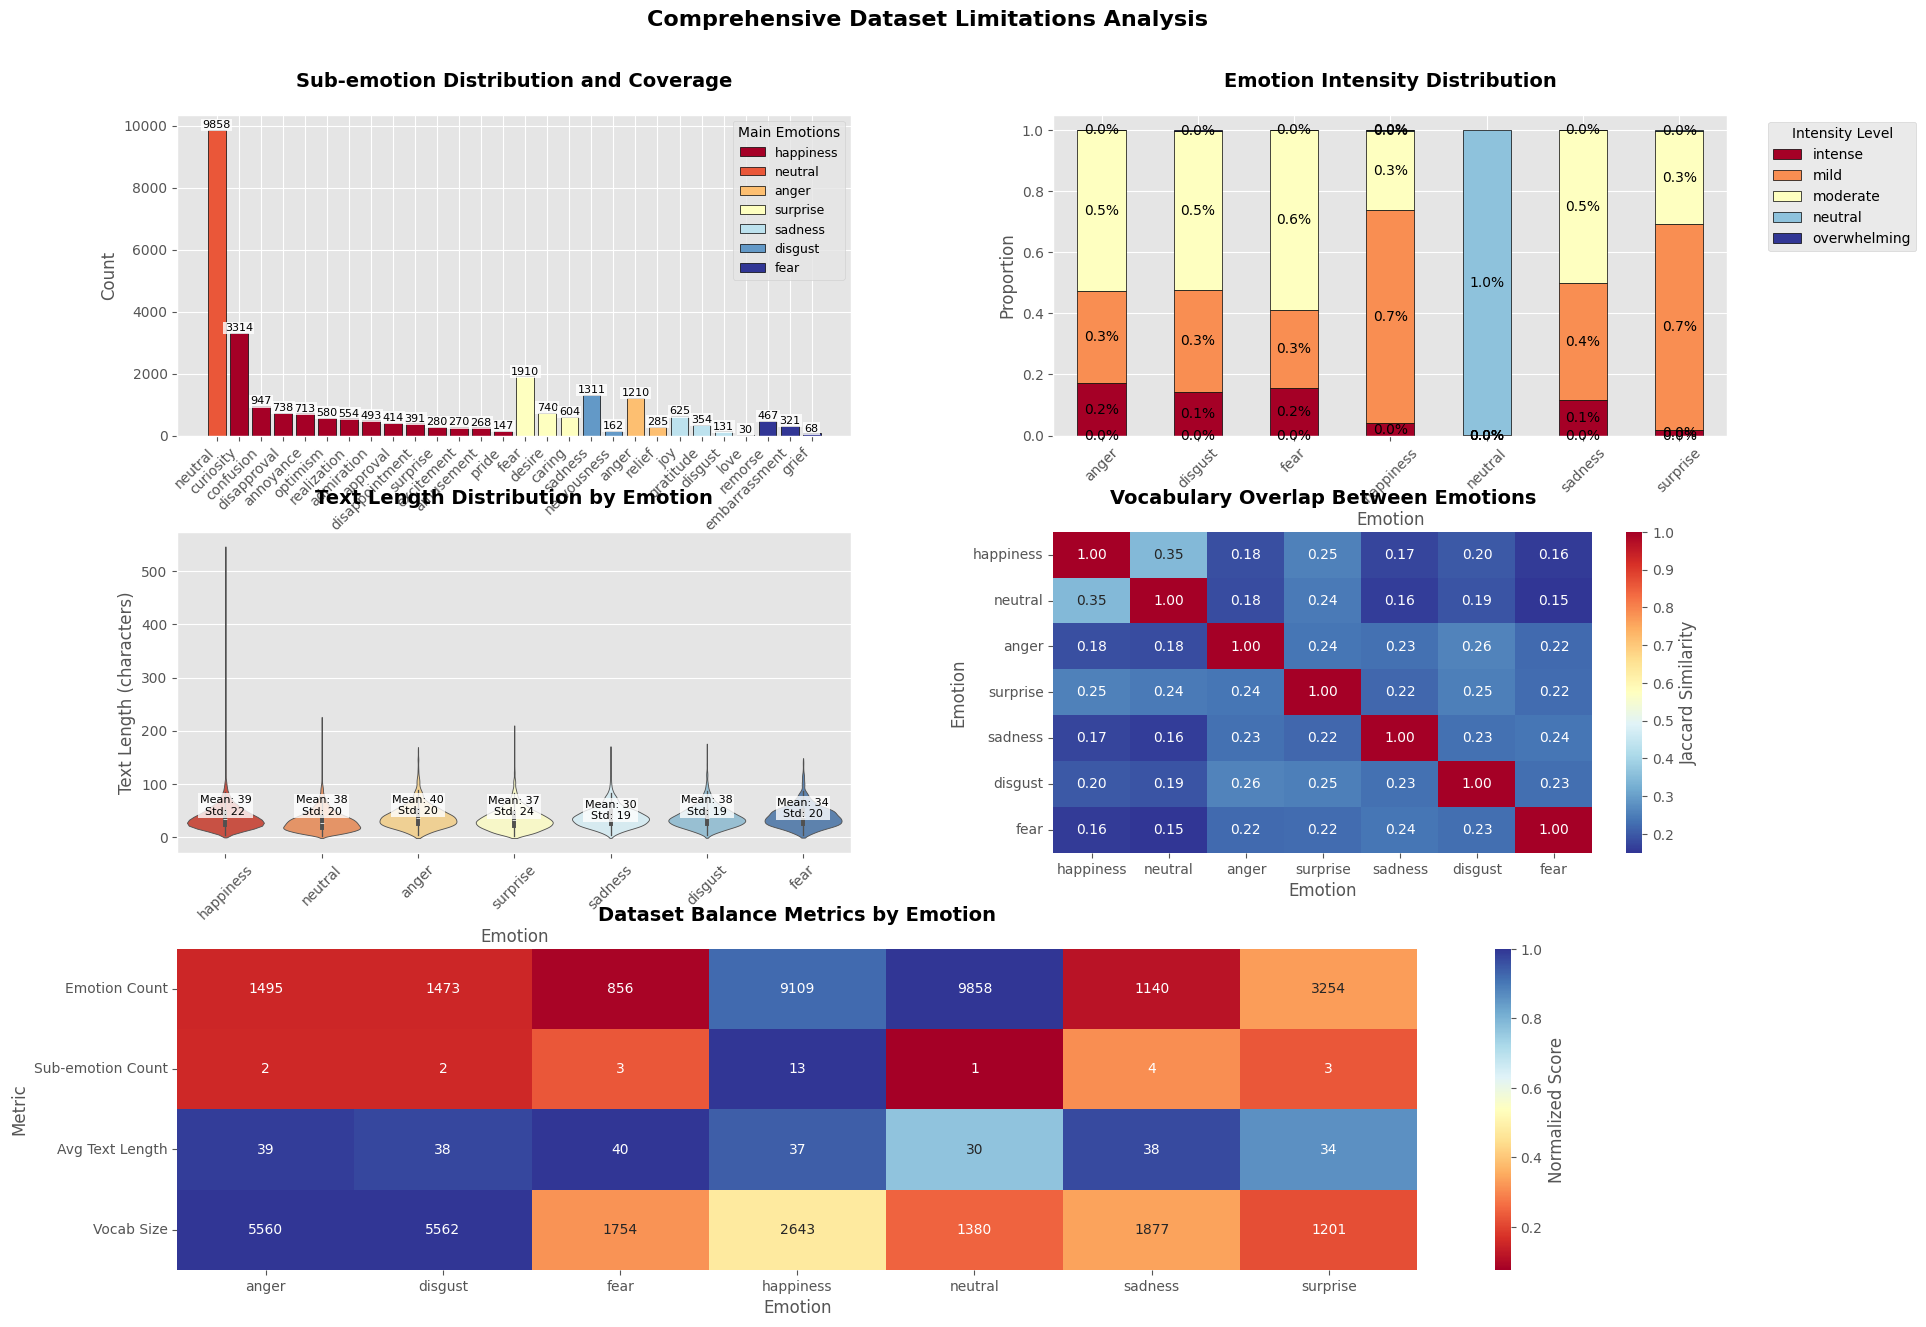


DATASET LIMITATIONS ANALYSIS REPORT

1. Sub-emotion Coverage:

NEUTRAL:
  • neutral: 9,858 samples (36.3%)

HAPPINESS:
  • curiosity: 3,314 samples (12.2%)
  • optimism: 947 samples (3.5%)
  • admiration: 738 samples (2.7%)
  • approval: 713 samples (2.6%)
  • excitement: 580 samples (2.1%)
  • amusement: 554 samples (2.0%)
  • pride: 493 samples (1.8%)
  • desire: 414 samples (1.5%)
  • caring: 391 samples (1.4%)
  • relief: 280 samples (1.0%)
  • joy: 270 samples (1.0%)
  • gratitude: 268 samples (1.0%)
  • love: 147 samples (0.5%)

SURPRISE:
  • confusion: 1,910 samples (7.0%)
  • realization: 740 samples (2.7%)
  • surprise: 604 samples (2.2%)

DISGUST:
  • disapproval: 1,311 samples (4.8%)
  • disgust: 162 samples (0.6%)

ANGER:
  • annoyance: 1,210 samples (4.5%)
  • anger: 285 samples (1.0%)

SADNESS:
  • disappointment: 625 samples (2.3%)
  • sadness: 354 samples (1.3%)
  • remorse: 131 samples (0.5%)
  • grief: 30 samples (0.1%)

FEAR:
  • fear: 467 samples (1.7%)
  • nervous

In [12]:
results = assessor.assess_limitations()

<br>

# Iteration 1

---

In the first iteration, we will establish a baseline model. The goal is to map "text" to "emotion", "sub-emotion", and "intensity" without using any feature extraction techniques. This will help us understand the model's performance at its most basic level.

In [13]:
# Hyperparameters
MODEL_NAME = "bert-base-multilingual-cased"
ITERATION_NUM = 1
MAX_LENGTH = 128
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUTPUT_TASKS = ['emotion', 'sub_emotion', 'intensity']

In [14]:
# Load the model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

loading configuration file config.json from cache at C:\Users\Soheil\.cache\huggingface\hub\models--bert-base-multilingual-cased\snapshots\3f076fdb1ab68d5b2880cb87a0886f315b8146f8\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.50.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 119547
}

loading file vocab.txt from ca

In [15]:
# Prepare data

# Features to use
feature_config = {
    'pos': False,
    'textblob': False,
    'vader': False,
    'tfidf': False,
    'emolex': False
}

# Initialize the data preparation
data_prep = DataPreparation(
    output_columns=OUTPUT_TASKS,
    tokenizer=tokenizer,  
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    feature_config=feature_config
)

# Prepare the data
train_dataloader, val_dataloader, test_dataloader = data_prep.prepare_data(
    train_df=df,
    test_df=test_df,  
    validation_split=0.1
)

# Get feature dimension from the feature extractor
feature_dim = data_prep.feature_extractor.get_feature_dim()

# Get number of classes for each output
num_classes = data_prep.get_num_classes()

# # Sample data using train_dataloader
# sample_data = next(iter(train_dataloader))
# print(sample_data)


Fitting TF-IDF vectorizer...
Extracting features for training data...


Processing training texts: 100%|██████████████████████████████████████████████| 27185/27185 [00:00<00:00, 654897.01it/s]


Extracting features for test data...


Processing test texts: 100%|██████████████████████████████████████████████████████████████████| 777/777 [00:00<?, ?it/s]


In [16]:
class BERTClassifier1(nn.Module):
    
    def __init__(self, model_name, feature_dim, num_classes, hidden_dim=256, dropout=0.1):
        super().__init__()
        
        # Load base BERT model
        self.bert = AutoModel.from_pretrained(model_name)
        
        # Get BERT embedding dimension
        bert_dim = self.bert.config.hidden_size
        
        # Feature projection layer
        self.feature_projection = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Combine BERT and feature embeddings
        combined_dim = bert_dim + hidden_dim
        
        # Task-specific layers
        self.emotion_classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes['emotion'])
        )
        
        self.sub_emotion_classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes['sub_emotion'])
        )
        
        self.intensity_classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes['intensity'])
        )
    
    def forward(self, input_ids, attention_mask, features):

        # Get BERT embeddings
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        bert_embeddings = bert_output.last_hidden_state[:, 0, :]  # Use [CLS] token
        
        # Project additional features
        projected_features = self.feature_projection(features)
        
        # Combine embeddings
        combined = torch.cat([bert_embeddings, projected_features], dim=1)
        
        # Task-specific predictions
        emotion_logits = self.emotion_classifier(combined)
        sub_emotion_logits = self.sub_emotion_classifier(combined)
        intensity_logits = self.intensity_classifier(combined)
        
        return emotion_logits, sub_emotion_logits, intensity_logits
    
# Initialize model
model = BERTClassifier1(
    model_name=MODEL_NAME,  # e.g. 'bert-base-uncased'
    feature_dim=feature_dim,  # Get this from feature extractor
    num_classes=num_classes,  # Get this from data_prep.get_num_classes()
    hidden_dim=256,  # Can be tuned
    dropout=0.1  # Can be tuned
).to(DEVICE)


loading configuration file config.json from cache at C:\Users\Soheil\.cache\huggingface\hub\models--bert-base-multilingual-cased\snapshots\3f076fdb1ab68d5b2880cb87a0886f315b8146f8\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.50.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 119547
}

loading weights file model.saf

In [20]:
# For emotion prediction only
trainer = CustomTrainer(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    test_dataloader=test_dataloader,
    device=DEVICE,
    test_set=test_df,
    class_weights_tensor=class_weights_tensor,
    iteration_num=ITERATION_NUM,
    encoders_dir='./results/encoders',
    output_tasks=OUTPUT_TASKS,
)

trainer.train_and_evaluate()

Epoch 1/5


Training:   0%|                                                                                | 0/1530 [00:00<?, ?it/s]

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 12.67it/s]


Train Loss: 3.7894

====================  Val Metrics  ====================
Loss: 3.2566
╒═════════════╤════════════════════╤═══════════════════╤════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score          │ Precision          │ Recall             │
╞═════════════╪════════════════════╪═══════════════════╪════════════════════╪════════════════════╡
│ emotion     │ 0.5075 ██████████  │ 0.5286 ██████████ │ 0.5781 ███████████ │ 0.5075 ██████████  │
├─────────────┼────────────────────┼───────────────────┼────────────────────┼────────────────────┤
│ sub_emotion │ 0.4535 █████████   │ 0.3668 ███████    │ 0.3680 ███████     │ 0.4535 █████████   │
├─────────────┼────────────────────┼───────────────────┼────────────────────┼────────────────────┤
│ intensity   │ 0.5550 ███████████ │ 0.5304 ██████████ │ 0.5191 ██████████  │ 0.5550 ███████████ │
╘═════════════╧════════════════════╧═══════════════════╧════════════════════╧════════════════════╛

===================

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:04<00:00, 11.72it/s]


...

Train Loss: 2.4441

====================  Val Metrics  ====================
Loss: 3.0148
╒═════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score           │ Precision           │ Recall             │
╞═════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5620 ███████████ │ 0.5791 ███████████ │ 0.6164 ████████████ │ 0.5620 ███████████ │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5097 ██████████  │ 0.4882 █████████   │ 0.4979 █████████    │ 0.5097 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5815 ███████████ │ 0.5668 ███████████ │ 0.6020 ████████████ │ 0.5815 ███████████ │
╘═════════════╧════════════════════╧════════════════════╧═════════════════════╧════════════════════╛

=

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:04<00:00, 12.24it/s]


Train Loss: 1.9781

====================  Val Metrics  ====================
Loss: 3.0740
╒═════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score           │ Precision           │ Recall             │
╞═════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5804 ███████████ │ 0.5936 ███████████ │ 0.6178 ████████████ │ 0.5804 ███████████ │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5245 ██████████  │ 0.5019 ██████████  │ 0.5035 ██████████   │ 0.5245 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5885 ███████████ │ 0.5768 ███████████ │ 0.5955 ███████████  │ 0.5885 ███████████ │
╘═════════════╧════════════════════╧════════════════════╧═════════════════════╧════════════════════╛

=

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:04<00:00, 11.44it/s]


Train Loss: 1.6440

====================  Val Metrics  ====================
Loss: 3.2115
╒═════════════╤════════════════════╤═════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score            │ Precision           │ Recall             │
╞═════════════╪════════════════════╪═════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5943 ███████████ │ 0.6039 ████████████ │ 0.6208 ████████████ │ 0.5943 ███████████ │
├─────────────┼────────────────────┼─────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5223 ██████████  │ 0.5060 ██████████   │ 0.5068 ██████████   │ 0.5223 ██████████  │
├─────────────┼────────────────────┼─────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5870 ███████████ │ 0.5759 ███████████  │ 0.5977 ███████████  │ 0.5870 ███████████ │
╘═════════════╧════════════════════╧═════════════════════╧═════════════════════╧═══════════════

Loading best model with test F1 score: 0.7409


Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 14.06it/s]



                         EMOTION CLASSIFICATION REPORT                          
              precision    recall  f1-score   support
       anger       0.08      0.60      0.14         5
     disgust       0.00      0.00      0.00         0
        fear       0.12      1.00      0.21         6
   happiness       0.07      0.65      0.13        34
     neutral       1.00      0.29      0.44       722
     sadness       0.04      1.00      0.08         2
    surprise       0.04      0.50      0.08         8
    accuracy                           0.31       777
   macro avg       0.19      0.58      0.15       777
weighted avg       0.93      0.31      0.42       777

                       SUB-EMOTION CLASSIFICATION REPORT                        
                precision    recall  f1-score   support
    admiration       0.08      0.58      0.15        12
     amusement       0.00      0.00      0.00         2
         anger       0.00      0.00      0.00         2
     annoyance    

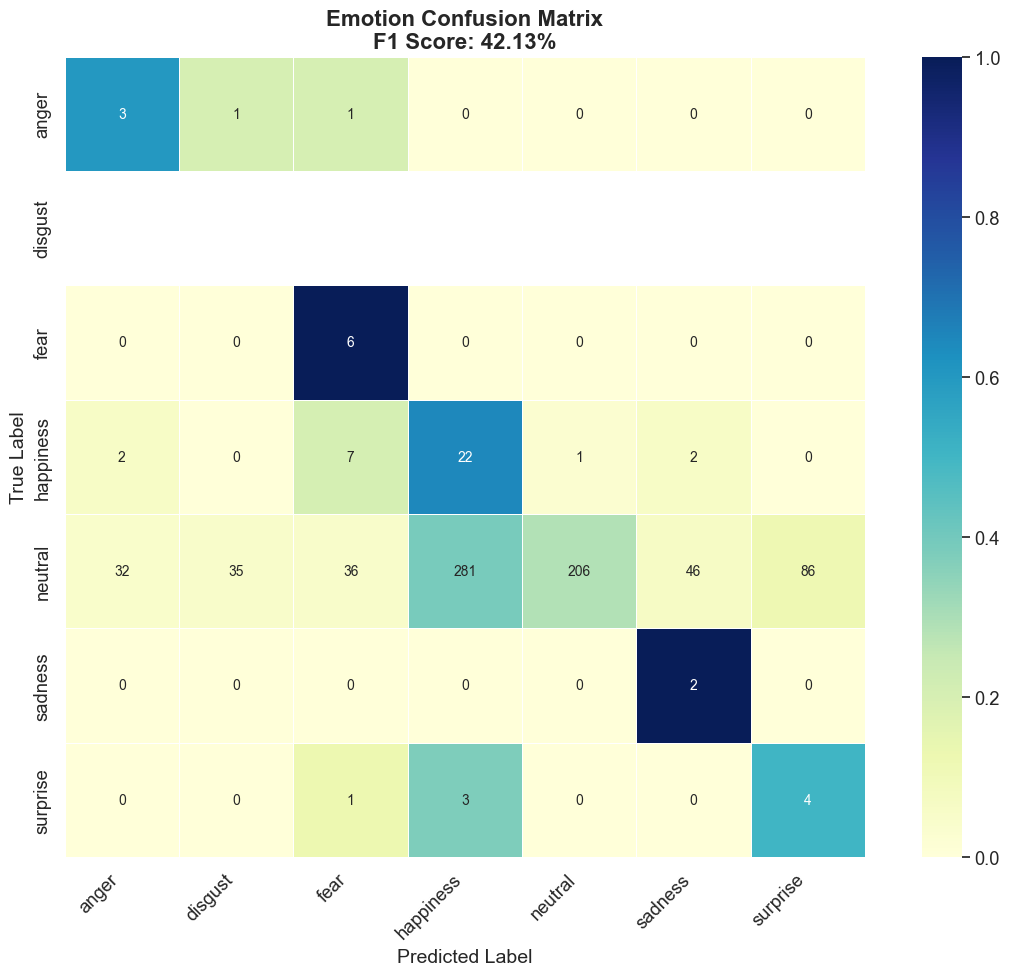

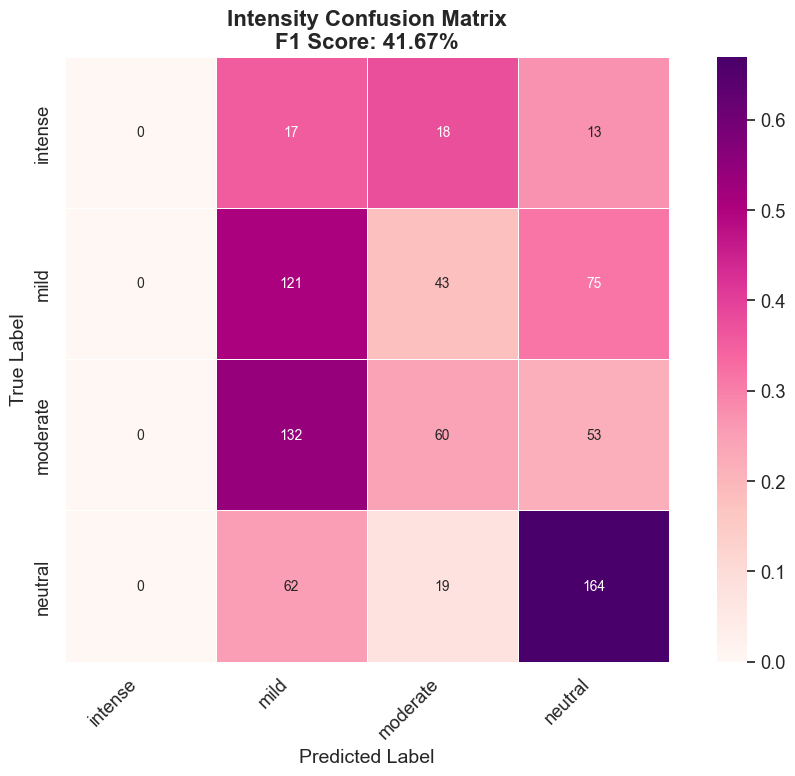

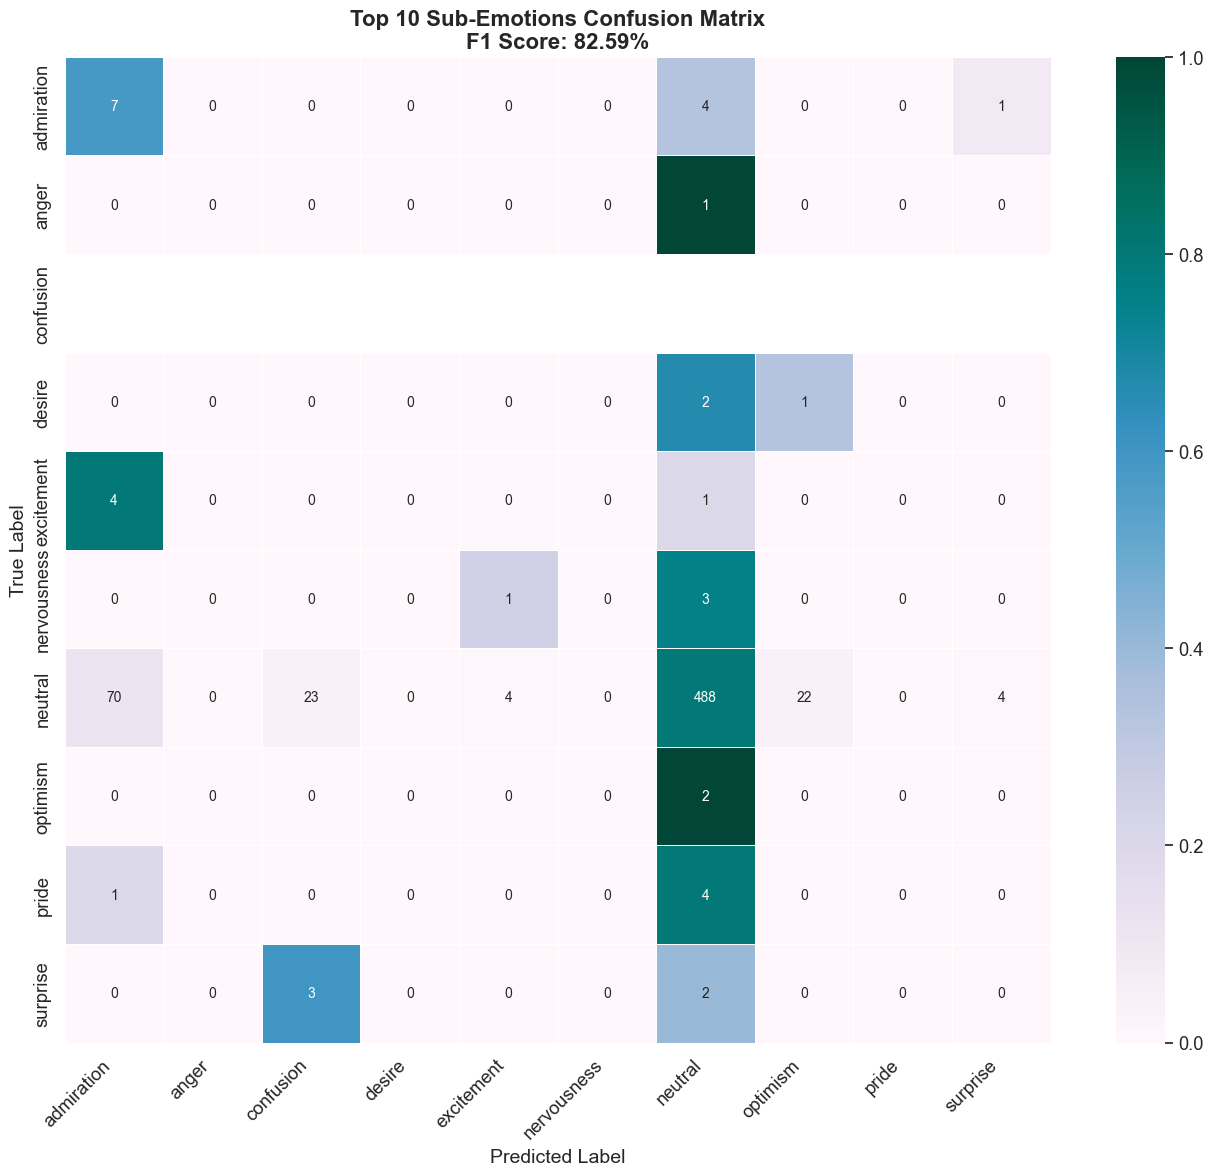

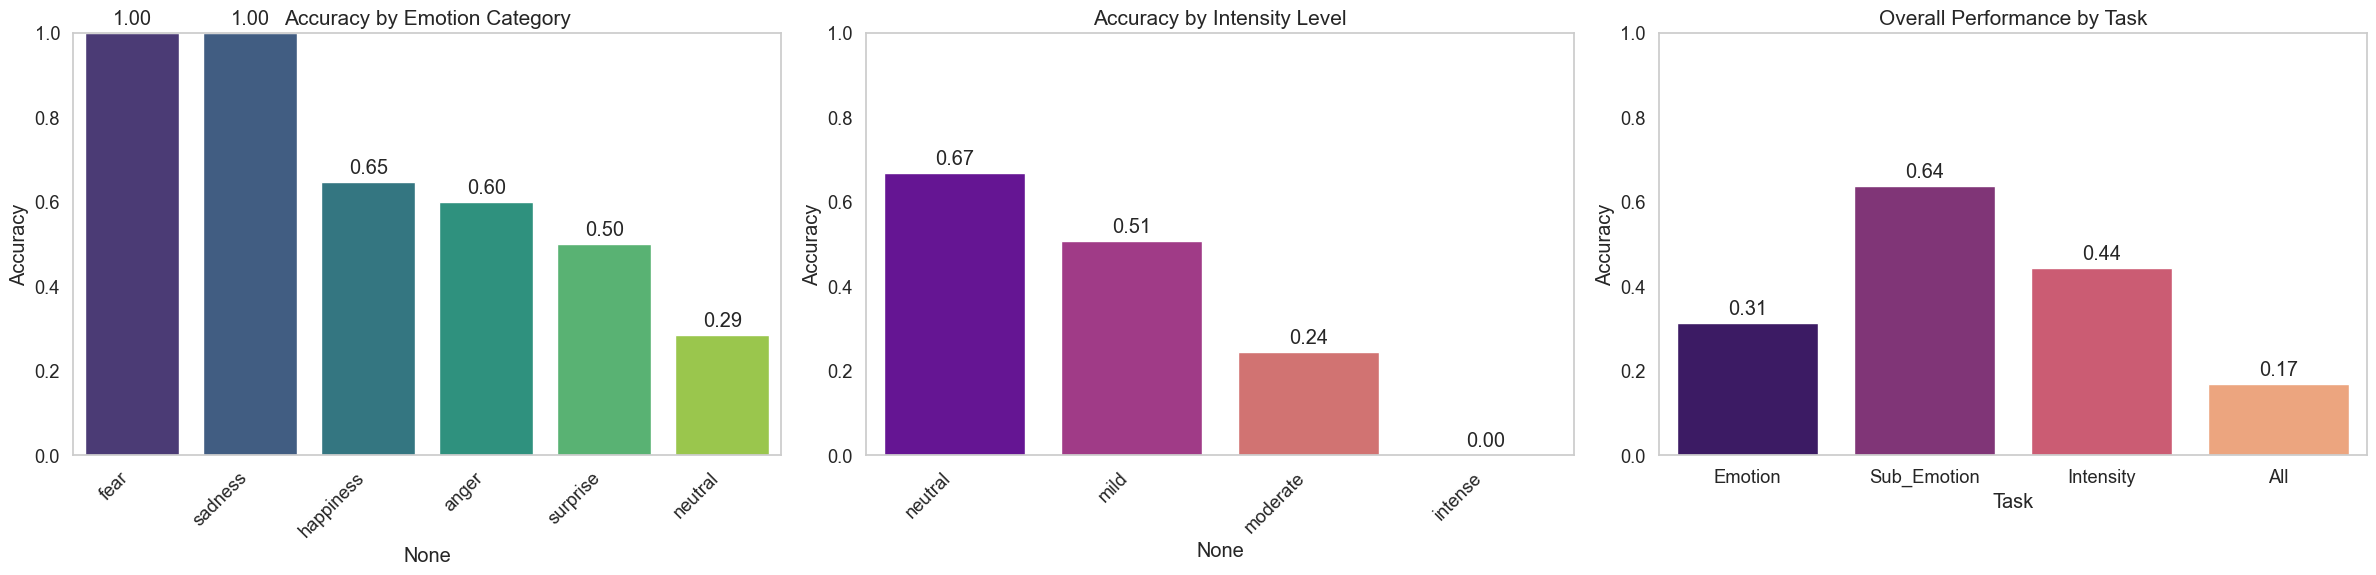


                           MISCLASSIFICATION EXAMPLES                           

Most problematic emotion: neutral
Examples of 'neutral' misclassified:

1. Text: I have no idea what I'm doing....
   True: neutral → Predicted: surprise
   Sub_emotion: neutral → confusion
   Intensity: moderate → mild

2. Text: It's Cindy she just walked across I was like, whoa...
   True: neutral → Predicted: surprise
   Sub_emotion: neutral → neutral
   Intensity: intense → mild

3. Text: so much emotion...
   True: neutral → Predicted: happiness
   Sub_emotion: neutral → admiration
   Intensity: moderate → mild

4. Text: 14 beautiful women from all across Asia...
   True: neutral → Predicted: happiness
   Sub_emotion: neutral → admiration
   Intensity: neutral → mild

5. Text: It's supposed to be me....
   True: neutral → Predicted: surprise
   Sub_emotion: neutral → neutral
   Intensity: moderate → mild


,text,true_emotion,pred_emotion,true_sub_emotion,pred_sub_emotion,true_intensity,pred_intensity,emotion_correct,sub_emotion_correct,intensity_correct,all_correct
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,anger,excitement,annoyance,intense,moderate,False,False,False,False
1,Thousands of model hopefuls from all over Asia...,neutral,happiness,neutral,optimism,moderate,mild,False,False,False,False
2,But only the standout modeling talent were cho...,neutral,happiness,neutral,admiration,moderate,mild,False,False,False,False
3,Prepare for an adventure of a lifetime,happiness,happiness,excitement,approval,intense,mild,True,False,False,False
4,All I can say girls for this fierce fifth seas...,happiness,happiness,excitement,admiration,moderate,mild,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
772,Maybe I should have like just shown it at firs...,neutral,sadness,neutral,neutral,moderate,moderate,False,True,True,False
773,So even though I'm the first girl to get elimi...,sadness,sadness,disappointment,neutral,moderate,moderate,True,False,True,False
774,Won't give up. I'll stand up after this,neutral,fear,neutral,neutral,intense,moderate,False,True,False,False
775,Next time on Asia's Next Top Model,happiness,happiness,neutral,neutral,neutral,mild,True,True,False,False


In [23]:
# Evaluate the model
trainer.evaluate_final_model()

Predicting on test set: 100%|██████████| 49/49 [00:03<00:00, 13.70it/s]


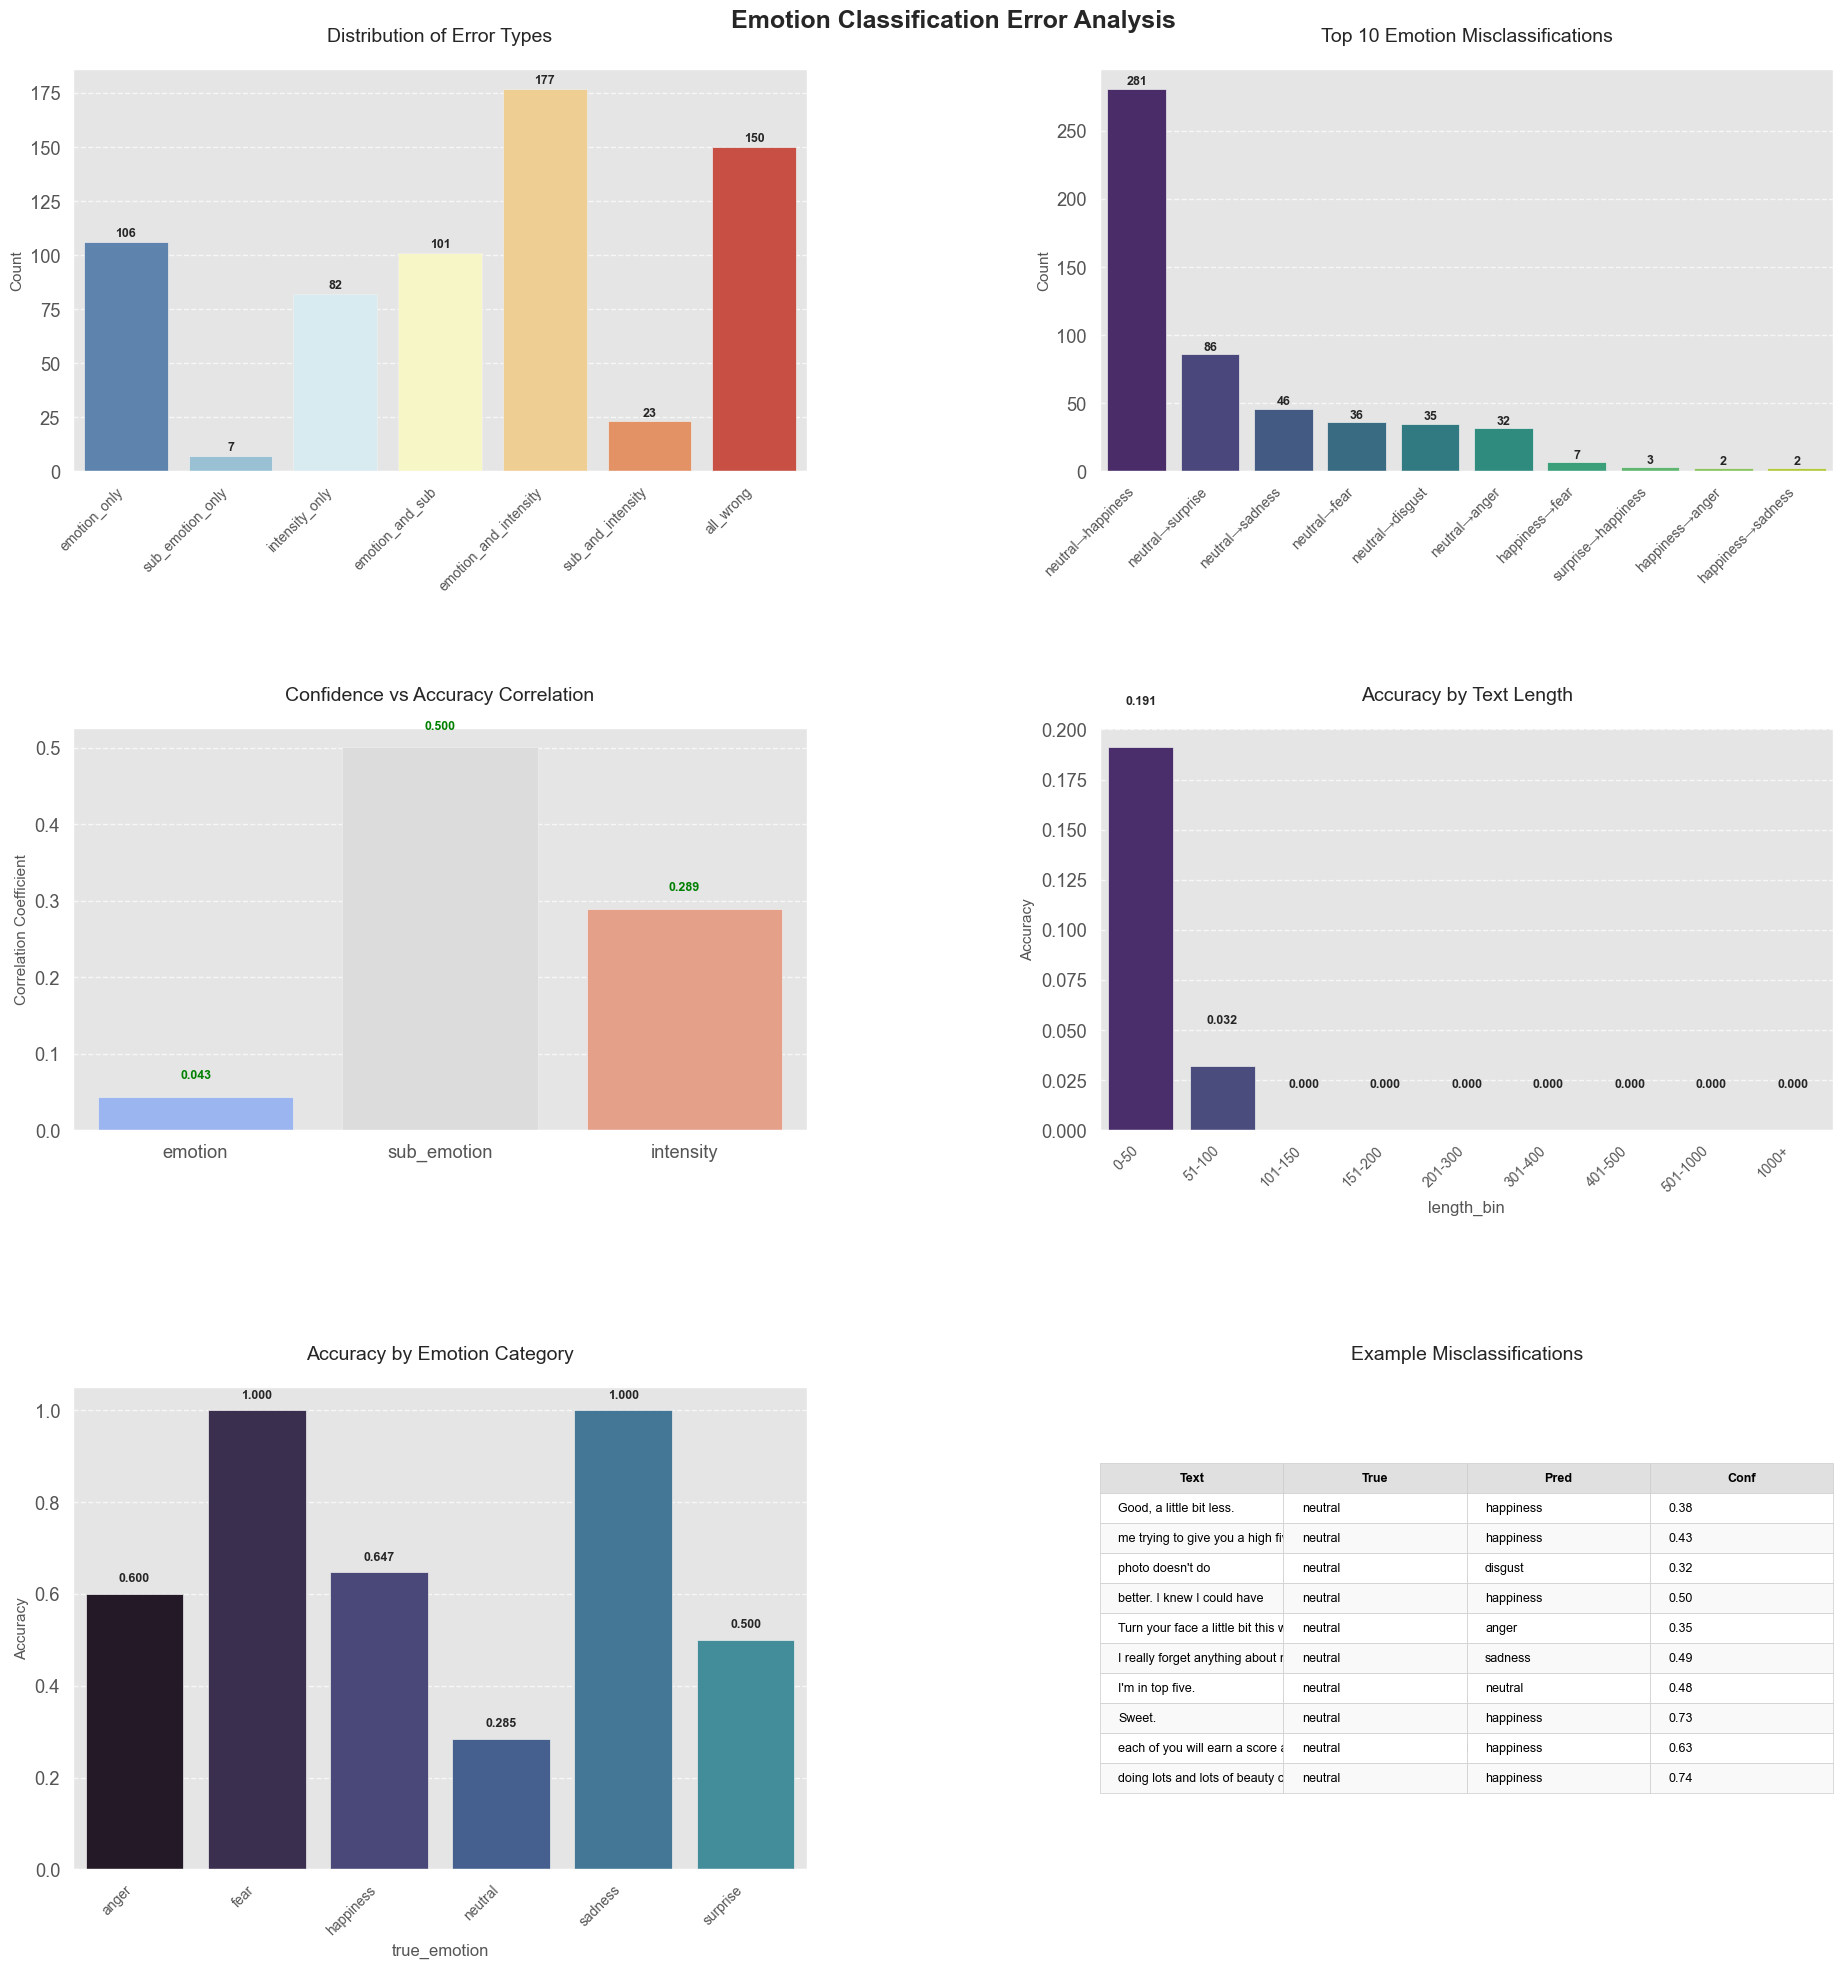


Most common error: true emotion 'neutral' predicted as 'happiness'
Total instances: 281
Average confidence: 0.586

Example 1:
----------------------------------------
Text: It's my very first photo challenge...
Length: 34 characters
Confidence: 0.543
True emotion: neutral
Predicted: happiness
Sub-emotion: neutral → neutral
Intensity: moderate → mild
----------------------------------------

Example 2:
----------------------------------------
Text: every single one of you has a very good chance...
Length: 46 characters
Confidence: 0.753
True emotion: neutral
Predicted: happiness
Sub-emotion: neutral → admiration
Intensity: moderate → mild
----------------------------------------

Example 3:
----------------------------------------
Text: Good luck, girls....
Length: 17 characters
Confidence: 0.701
True emotion: neutral
Predicted: happiness
Sub-emotion: neutral → approval
Intensity: mild → mild
----------------------------------------

Example 4:
----------------------------------------


In [ ]:
# Error analysis

# Initialize the error analysis with custom configuration
config = AnalysisConfig(
    figure_size=(15, 10),  
    font_size={'title': 14, 'label': 11, 'tick': 9, 'annotation': 9}, 
    color_palette="deep",  
    max_text_length=100,  
    example_count=10,  
    correlation_threshold=0.15,  
    save_plots=True,
    plot_format="png",
    output_dir="./results/error_analysis" 
)

# Initialize the error analyzer
error_analyzer = ErrorAnalysis(
    model=model,
    test_dataloader=test_dataloader,
    device=DEVICE,
    train_df=df,
    test_df=test_df,
    config=config
)

# Run the analysis
results_df, correct_df, error_df = error_analyzer.analyze_errors()
error_analysis = error_analyzer.analyze_error_patterns()

# Visualize results with automatic display in notebook
error_analyzer.visualize_error_patterns()

# Examine specific errors (reduced examples for cleaner notebook output)
error_analyzer.examine_specific_errors(n_examples=5)

# Generate recommendations
recommendations = error_analyzer.generate_recommendations()

# Save results (assuming we're in iteration 1 based on notebook context)
error_analyzer.save_results(iteration_num=ITERATION_NUM)

#### Error Analysis Result

Based on the error analysis provided, here's a concise analysis of the key findings from iteration 1:

1. **Major Classification Issue**: The model shows a strong bias towards misclassifying neutral text as expressing happiness, with 281 such misclassifications. This suggests the model is overly sensitive to positive language cues.

2. **Confidence Pattern**: The model's average confidence in these misclassifications is moderate (0.586), indicating it's somewhat hesitant in these wrong predictions. Looking at the examples, confidence ranges from 0.543 to 0.757, showing inconsistent certainty levels.

3. **Pattern in Errors**: The examples reveal that the model tends to interpret polite, friendly, or supportive neutral statements (e.g., "Good luck", "gorgeous faces") as expressions of happiness. This suggests the model needs better training to distinguish between neutral politeness and genuine happiness expressions.

4. **Overall Performance**: With an overall accuracy of just 0.169 and 646 total errors, the model's performance needs significant improvement. The fact that 79.88% of errors involve neutral emotions indicates a critical need to better handle neutral cases.

5. **Hierarchical Performance**: The sub-emotion accuracy (0.638) is notably better than the base emotion accuracy, suggesting the model might benefit from a more hierarchical approach to classification.


<br>

# Iteration 2 

---

Following iteration 1's error analysis revealing significant neutral-happiness confusion, we introduce comprehensive feature extraction using POS tagging, TextBlob, VADER, and TF-IDF to improve the model's ability to distinguish neutral from emotional expressions.

In [25]:
# Hyperparameters
MODEL_NAME = "bert-base-multilingual-cased"
ITERATION_NUM = 2
MAX_LENGTH = 128
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUTPUT_TASKS = ['emotion', 'sub_emotion', 'intensity']

In [26]:
# Load the model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

loading configuration file config.json from cache at C:\Users\Soheil\.cache\huggingface\hub\models--bert-base-multilingual-cased\snapshots\3f076fdb1ab68d5b2880cb87a0886f315b8146f8\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.50.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 119547
}

loading file vocab.txt from ca

In [27]:
# Prepare data

# Features to use
feature_config = {
    'pos': True,
    'textblob': True,
    'vader': True,
    'tfidf': True,
    'emolex': False
}

# Initialize the data preparation
data_prep = DataPreparation(
    output_columns=OUTPUT_TASKS,
    tokenizer=tokenizer,  
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    feature_config=feature_config
)

# Prepare the data
train_dataloader, val_dataloader, test_dataloader = data_prep.prepare_data(
    train_df=df,
    test_df=test_df,  
    validation_split=0.1
)

# Get feature dimension from the feature extractor
feature_dim = data_prep.feature_extractor.get_feature_dim()

# Get number of classes for each output
num_classes = data_prep.get_num_classes()

# # Sample data using train_dataloader
# sample_data = next(iter(train_dataloader))
# print(sample_data)


Fitting TF-IDF vectorizer...
Extracting features for training data...


Processing training texts: 100%|████████████████████████████████████████████████| 27185/27185 [00:22<00:00, 1224.30it/s]


Extracting features for test data...


Processing test texts: 100%|████████████████████████████████████████████████████████| 777/777 [00:00<00:00, 1260.08it/s]


In [28]:
class BERTClassifier2(nn.Module):
    
    def __init__(self, model_name, feature_dim, num_classes, hidden_dim=256, dropout=0.1):
        super().__init__()
        
        # Load base BERT model
        self.bert = AutoModel.from_pretrained(model_name)
        
        # Get BERT embedding dimension
        bert_dim = self.bert.config.hidden_size
        
        # Feature projection layer
        self.feature_projection = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Combine BERT and feature embeddings
        combined_dim = bert_dim + hidden_dim
        
        # Task-specific layers
        self.emotion_classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes['emotion'])
        )
        
        self.sub_emotion_classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes['sub_emotion'])
        )
        
        self.intensity_classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes['intensity'])
        )
    
    def forward(self, input_ids, attention_mask, features):

        # Get BERT embeddings
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        bert_embeddings = bert_output.last_hidden_state[:, 0, :]  # Use [CLS] token
        
        # Project additional features
        projected_features = self.feature_projection(features)
        
        # Combine embeddings
        combined = torch.cat([bert_embeddings, projected_features], dim=1)
        
        # Task-specific predictions
        emotion_logits = self.emotion_classifier(combined)
        sub_emotion_logits = self.sub_emotion_classifier(combined)
        intensity_logits = self.intensity_classifier(combined)
        
        return emotion_logits, sub_emotion_logits, intensity_logits
    
# Initialize model
model = BERTClassifier2(
    model_name=MODEL_NAME,  # e.g. 'bert-base-uncased'
    feature_dim=feature_dim,  # Get this from feature extractor
    num_classes=num_classes,  # Get this from data_prep.get_num_classes()
    hidden_dim=256,  # Can be tuned
    dropout=0.1  # Can be tuned
).to(DEVICE)


loading configuration file config.json from cache at C:\Users\Soheil\.cache\huggingface\hub\models--bert-base-multilingual-cased\snapshots\3f076fdb1ab68d5b2880cb87a0886f315b8146f8\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.50.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 119547
}

loading weights file model.saf

In [29]:
# For emotion prediction only
trainer = CustomTrainer(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    test_dataloader=test_dataloader,
    device=DEVICE,
    test_set=test_df,
    class_weights_tensor=class_weights_tensor,
    iteration_num=ITERATION_NUM,
    encoders_dir='./results/encoders',
    output_tasks=OUTPUT_TASKS,
)

trainer.train_and_evaluate()

Epoch 1/5


Training:   0%|                                                                                | 0/1530 [00:00<?, ?it/s]

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 12.87it/s]


Train Loss: 3.8249

====================  Val Metrics  ====================
Loss: 3.3298
╒═════════════╤═══════════════════╤═══════════════════╤════════════════════╤═══════════════════╕
│ Task        │ Accuracy          │ F1 Score          │ Precision          │ Recall            │
╞═════════════╪═══════════════════╪═══════════════════╪════════════════════╪═══════════════════╡
│ emotion     │ 0.4605 █████████  │ 0.5011 ██████████ │ 0.5865 ███████████ │ 0.4605 █████████  │
├─────────────┼───────────────────┼───────────────────┼────────────────────┼───────────────────┤
│ sub_emotion │ 0.4623 █████████  │ 0.3868 ███████    │ 0.3842 ███████     │ 0.4623 █████████  │
├─────────────┼───────────────────┼───────────────────┼────────────────────┼───────────────────┤
│ intensity   │ 0.5469 ██████████ │ 0.5391 ██████████ │ 0.5367 ██████████  │ 0.5469 ██████████ │
╘═════════════╧═══════════════════╧═══════════════════╧════════════════════╧═══════════════════╛

====================  Test Metrics  =

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 13.57it/s]


...

Train Loss: 2.4521

====================  Val Metrics  ====================
Loss: 3.0519
╒═════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score           │ Precision           │ Recall             │
╞═════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5428 ██████████  │ 0.5629 ███████████ │ 0.6104 ████████████ │ 0.5428 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5101 ██████████  │ 0.4812 █████████   │ 0.4869 █████████    │ 0.5101 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5932 ███████████ │ 0.5835 ███████████ │ 0.5992 ███████████  │ 0.5932 ███████████ │
╘═════════════╧════════════════════╧════════════════════╧═════════════════════╧════════════════════╛

=

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 13.76it/s]


Train Loss: 1.9839

====================  Val Metrics  ====================
Loss: 3.1566
╒═════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score           │ Precision           │ Recall             │
╞═════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5756 ███████████ │ 0.5870 ███████████ │ 0.6114 ████████████ │ 0.5756 ███████████ │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5167 ██████████  │ 0.4981 █████████   │ 0.4958 █████████    │ 0.5167 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5837 ███████████ │ 0.5737 ███████████ │ 0.5949 ███████████  │ 0.5837 ███████████ │
╘═════════════╧════════════════════╧════════════════════╧═════════════════════╧════════════════════╛

=

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 13.62it/s]


Train Loss: 1.6494

====================  Val Metrics  ====================
Loss: 3.2445
╒═════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score           │ Precision           │ Recall             │
╞═════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5752 ███████████ │ 0.5860 ███████████ │ 0.6048 ████████████ │ 0.5752 ███████████ │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5101 ██████████  │ 0.4936 █████████   │ 0.4918 █████████    │ 0.5101 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5800 ███████████ │ 0.5704 ███████████ │ 0.5931 ███████████  │ 0.5800 ███████████ │
╘═════════════╧════════════════════╧════════════════════╧═════════════════════╧════════════════════╛

=

Loading best model with test F1 score: 0.6983


Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 13.50it/s]



                         EMOTION CLASSIFICATION REPORT                          
              precision    recall  f1-score   support
       anger       0.17      0.80      0.29         5
     disgust       0.00      0.00      0.00         0
        fear       0.05      1.00      0.09         6
   happiness       0.08      0.68      0.14        34
     neutral       1.00      0.22      0.37       722
     sadness       0.00      0.00      0.00         2
    surprise       0.07      0.62      0.12         8
    accuracy                           0.26       777
   macro avg       0.20      0.48      0.14       777
weighted avg       0.93      0.26      0.35       777

                       SUB-EMOTION CLASSIFICATION REPORT                        
                precision    recall  f1-score   support
    admiration       0.12      0.75      0.20        12
     amusement       0.00      0.00      0.00         2
         anger       0.00      0.00      0.00         2
     annoyance    

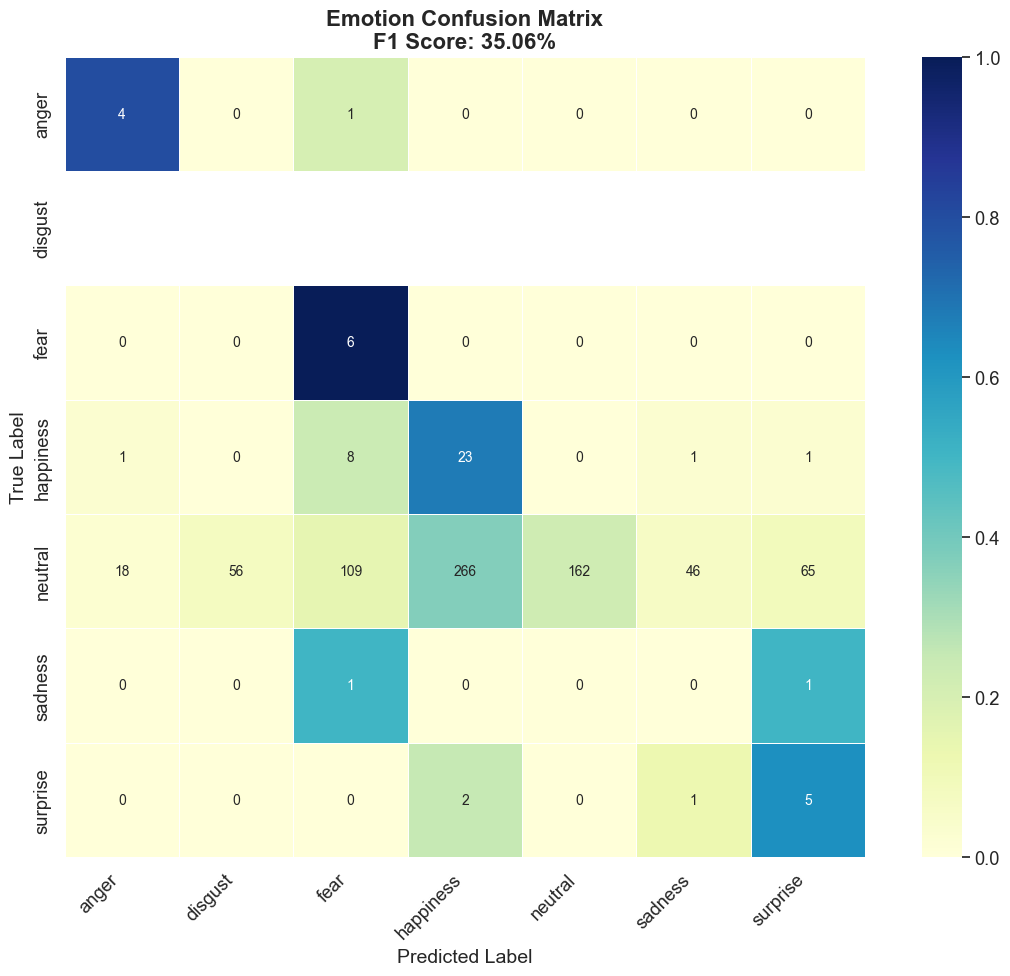

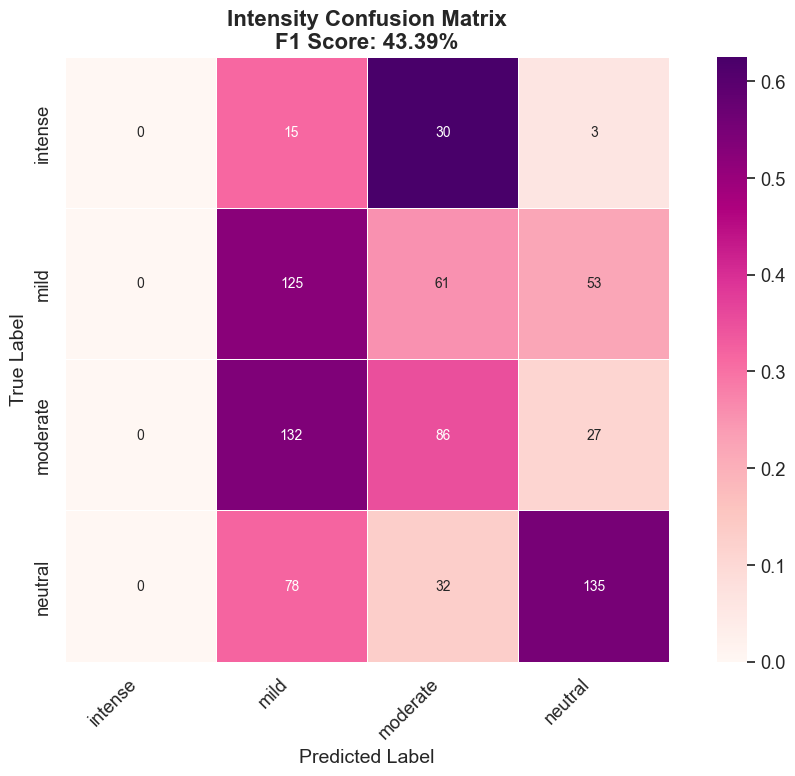

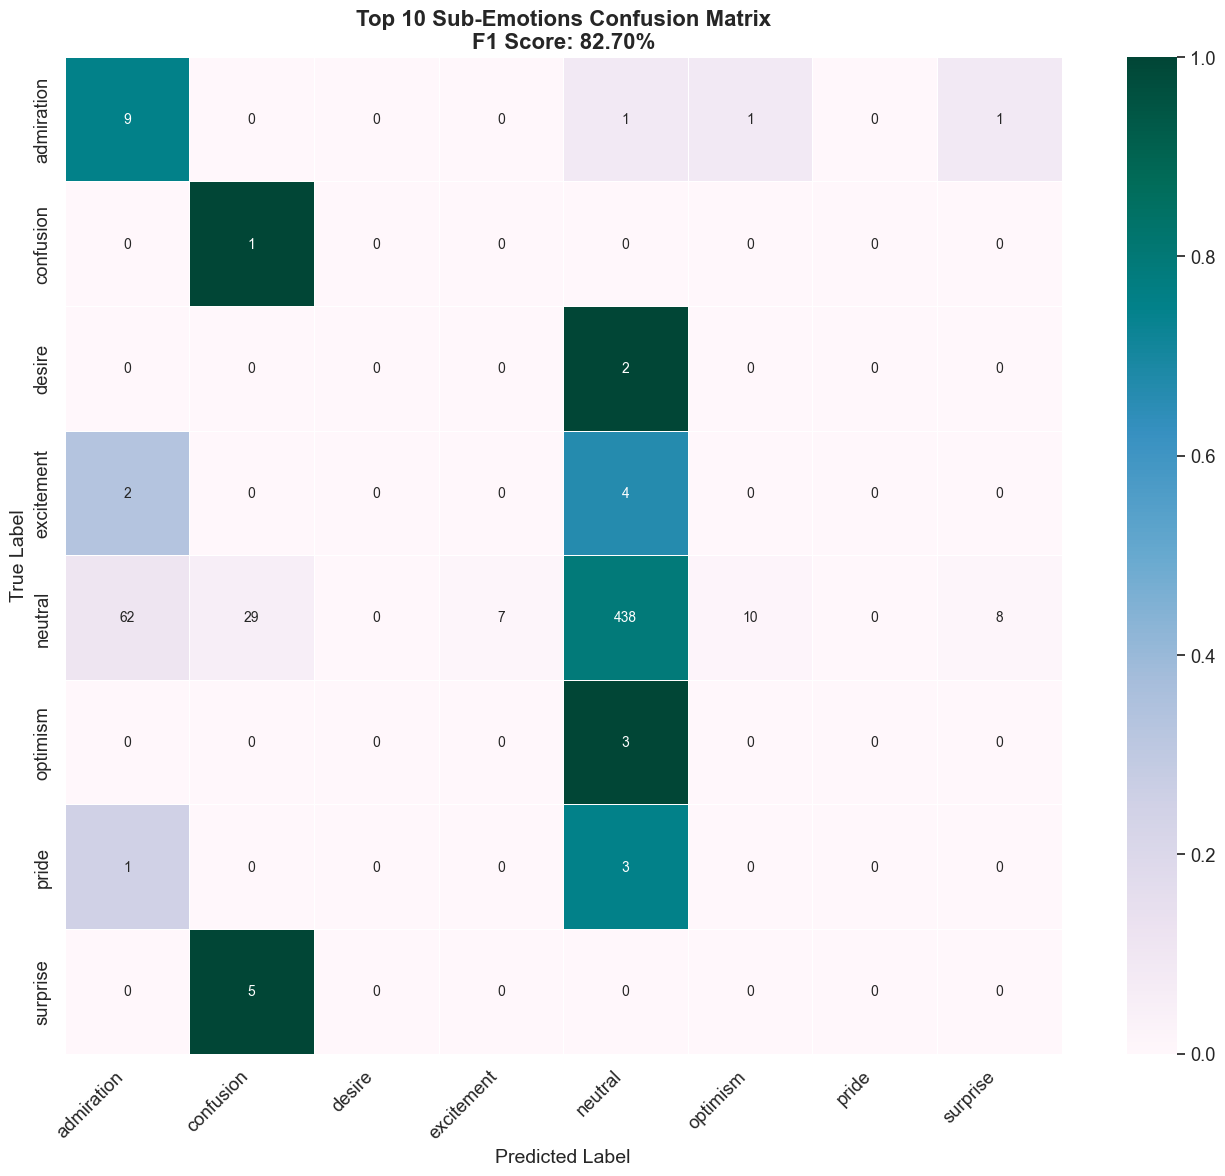

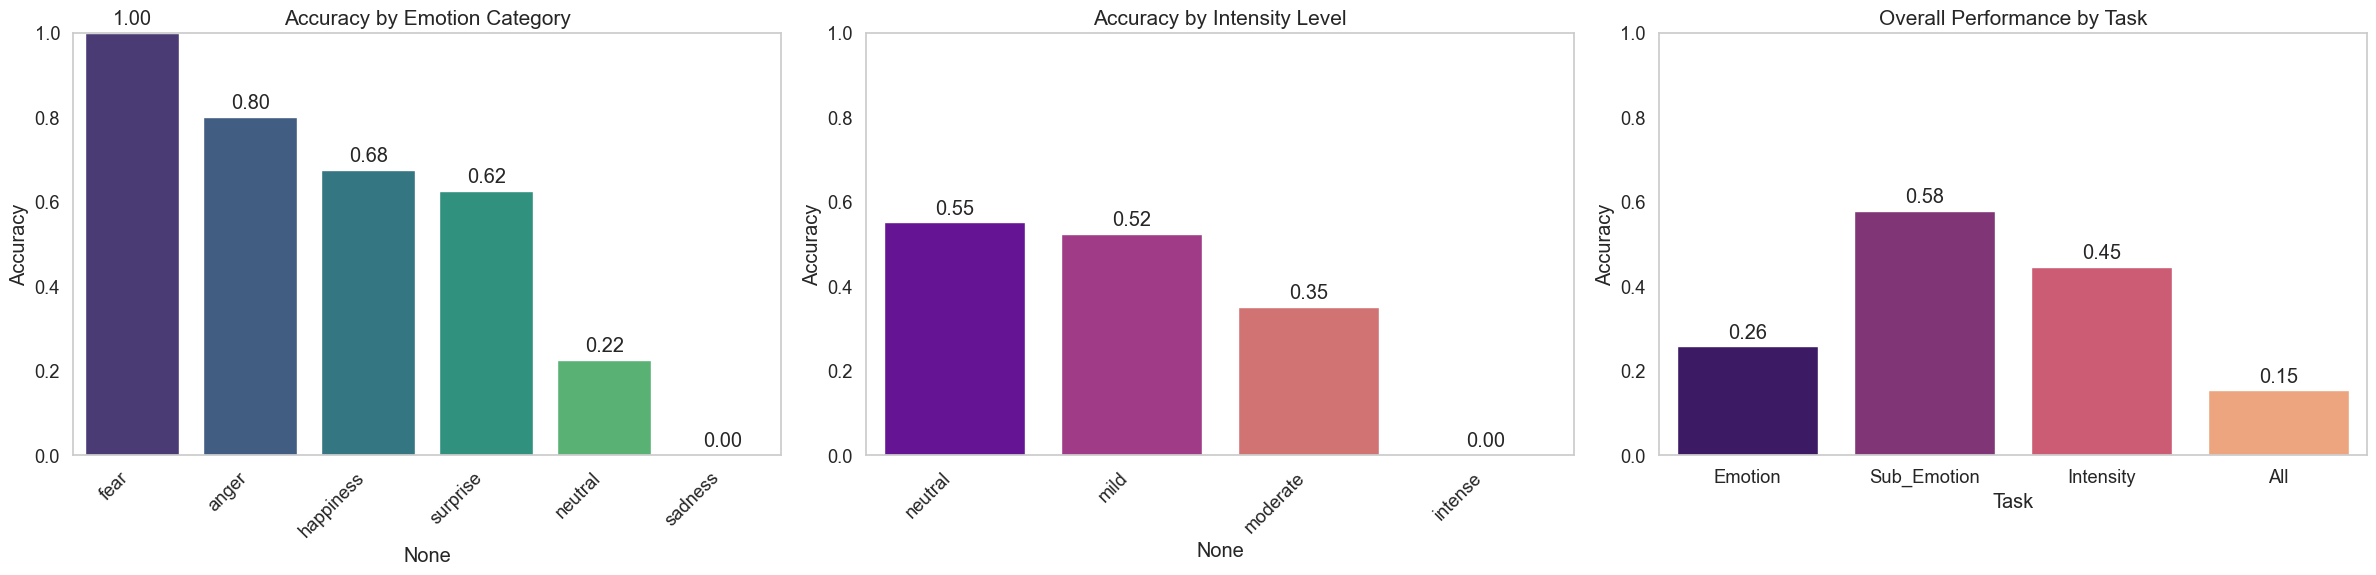


                           MISCLASSIFICATION EXAMPLES                           

Most problematic emotion: neutral
Examples of 'neutral' misclassified:

1. Text: me trying to give you a high five...
   True: neutral → Predicted: happiness
   Sub_emotion: neutral → curiosity
   Intensity: mild → mild

2. Text: I love your look....
   True: neutral → Predicted: happiness
   Sub_emotion: neutral → gratitude
   Intensity: moderate → mild

3. Text: Namita, let's see what you got, girlfriend....
   True: neutral → Predicted: happiness
   Sub_emotion: neutral → curiosity
   Intensity: neutral → mild

4. Text: This is a challenge....
   True: neutral → Predicted: happiness
   Sub_emotion: neutral → neutral
   Intensity: neutral → mild

5. Text: that you're actually in frame....
   True: neutral → Predicted: disgust
   Sub_emotion: neutral → neutral
   Intensity: neutral → mild


,text,true_emotion,pred_emotion,true_sub_emotion,pred_sub_emotion,true_intensity,pred_intensity,emotion_correct,sub_emotion_correct,intensity_correct,all_correct
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,fear,excitement,neutral,intense,moderate,False,False,False,False
1,Thousands of model hopefuls from all over Asia...,neutral,happiness,neutral,neutral,moderate,mild,False,True,False,False
2,But only the standout modeling talent were cho...,neutral,happiness,neutral,neutral,moderate,mild,False,True,False,False
3,Prepare for an adventure of a lifetime,happiness,happiness,excitement,neutral,intense,mild,True,False,False,False
4,All I can say girls for this fierce fifth seas...,happiness,fear,excitement,curiosity,moderate,moderate,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
772,Maybe I should have like just shown it at firs...,neutral,sadness,neutral,neutral,moderate,moderate,False,True,True,False
773,So even though I'm the first girl to get elimi...,sadness,fear,disappointment,fear,moderate,moderate,False,False,True,False
774,Won't give up. I'll stand up after this,neutral,fear,neutral,neutral,intense,moderate,False,True,False,False
775,Next time on Asia's Next Top Model,happiness,happiness,neutral,neutral,neutral,mild,True,True,False,False


In [30]:
# Evaluate the model
trainer.evaluate_final_model()

Predicting on test set: 100%|██████████| 49/49 [00:03<00:00, 13.72it/s]


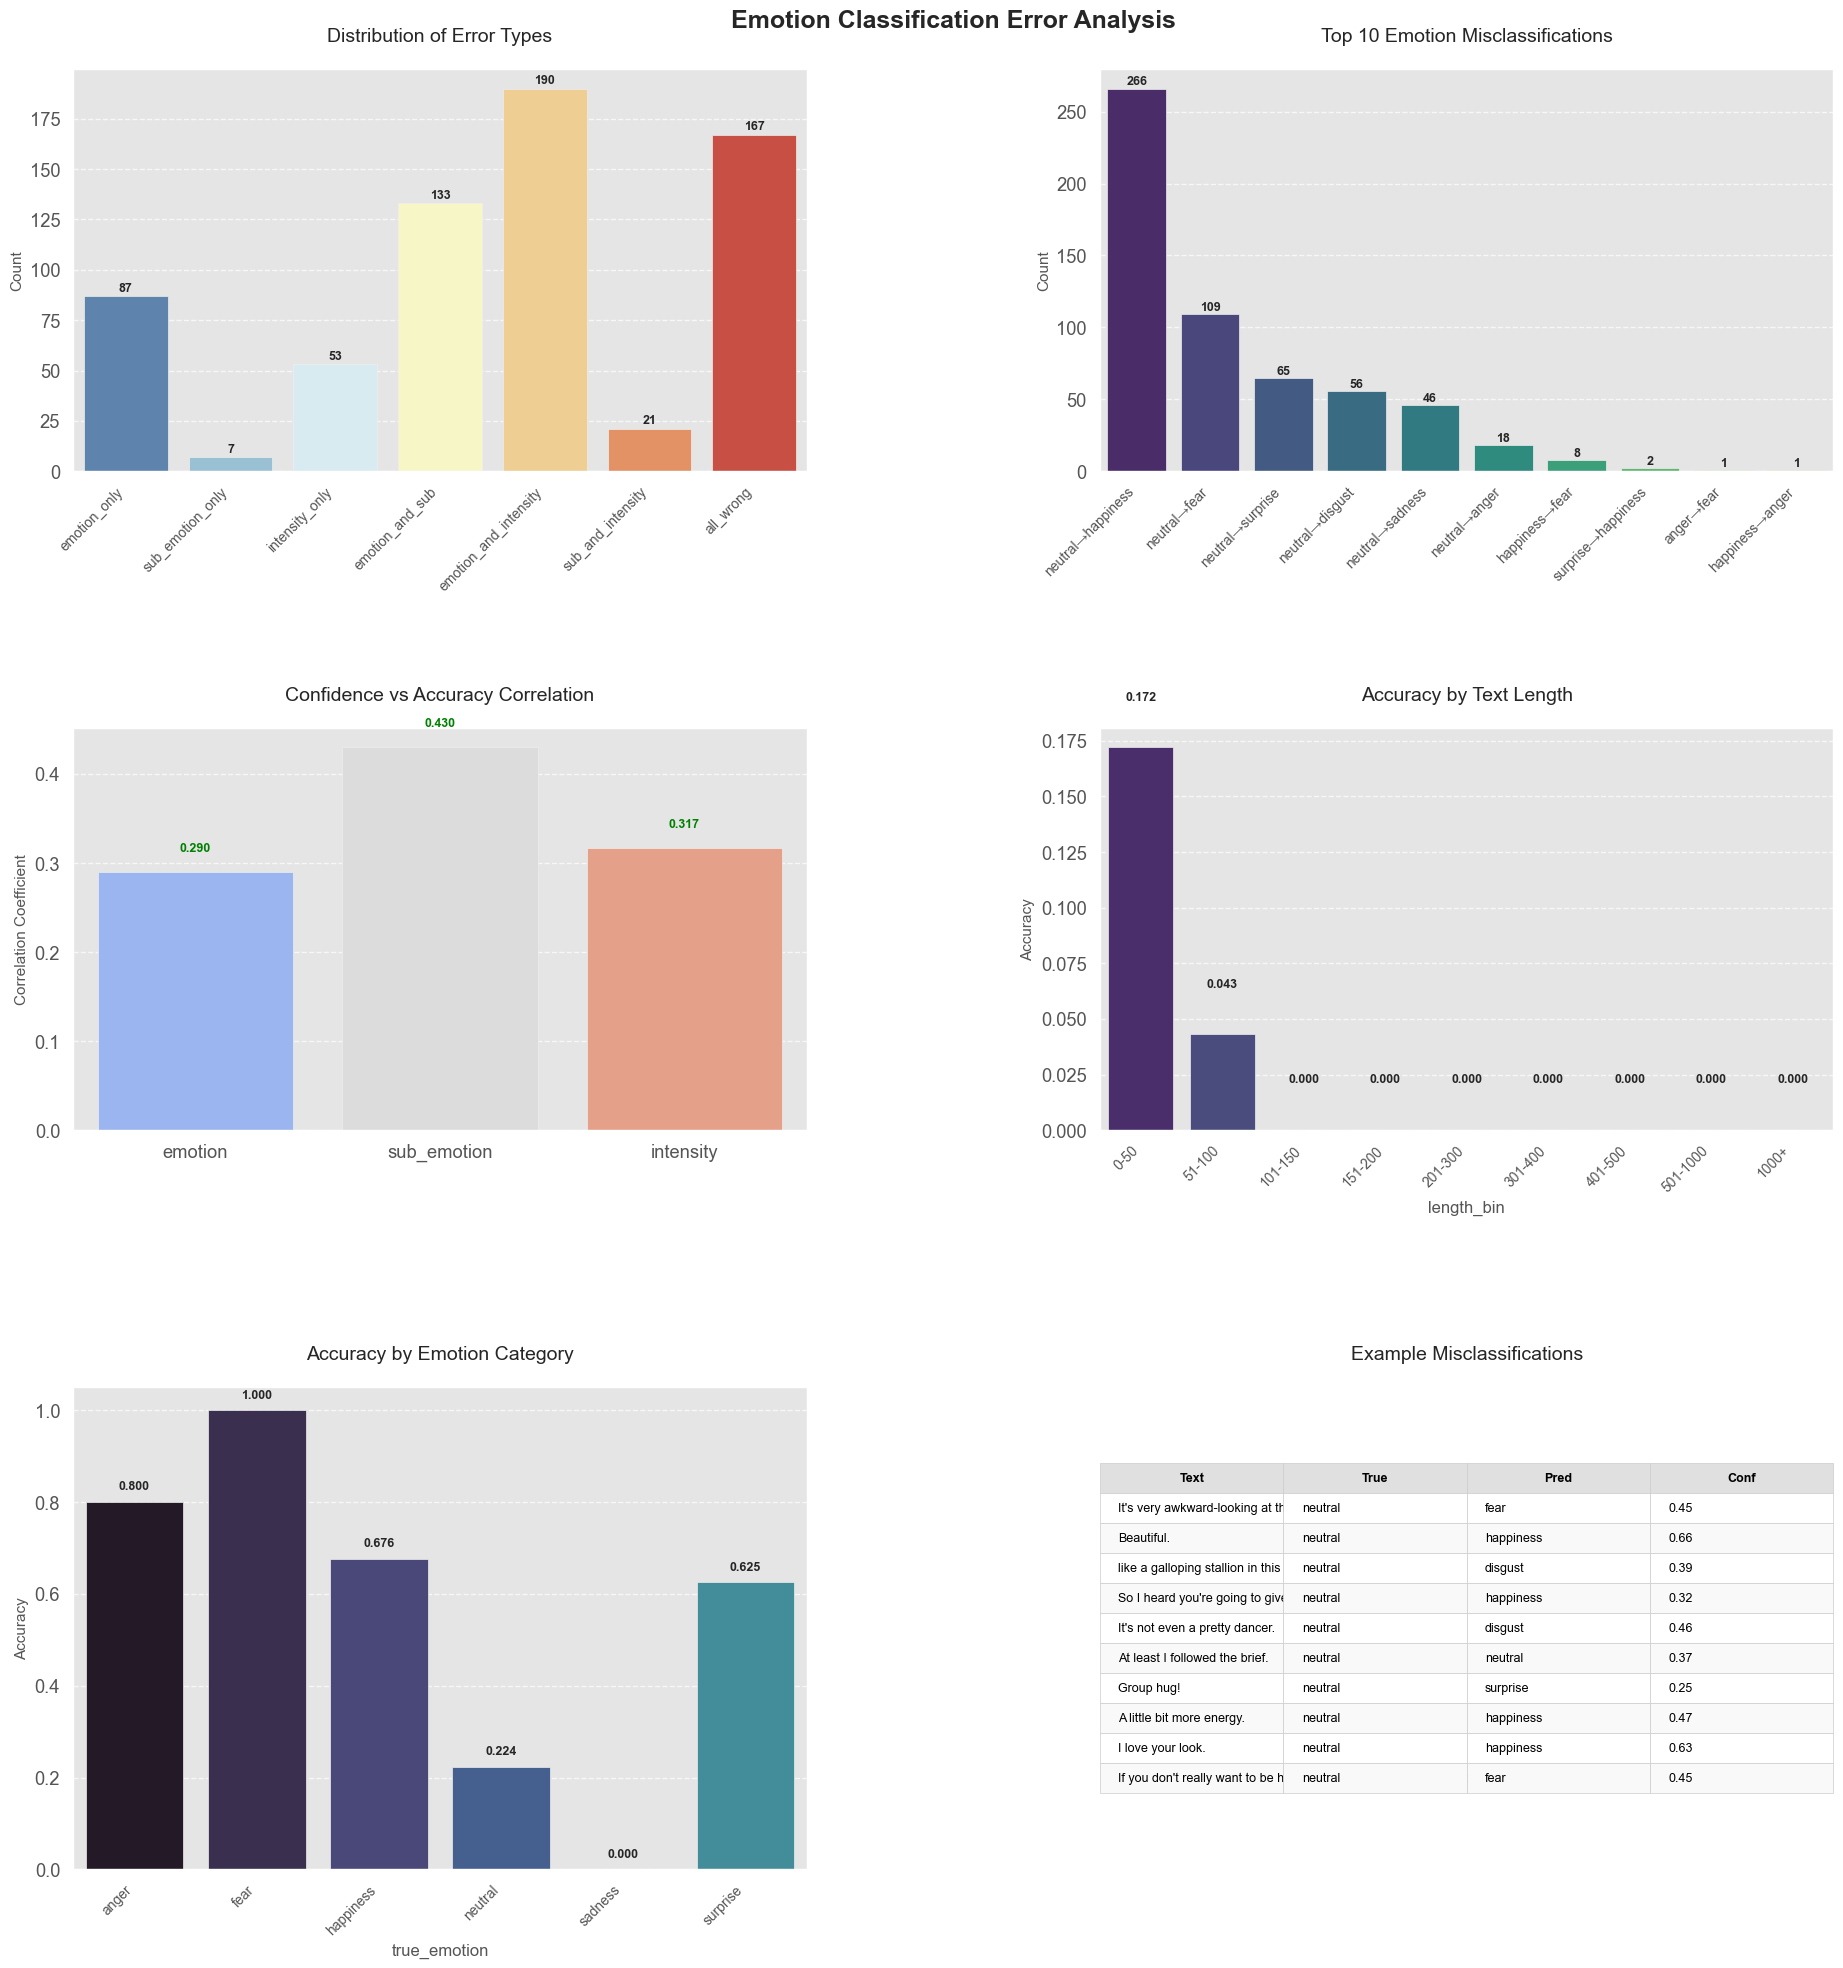


Most common error: true emotion 'neutral' predicted as 'happiness'
Total instances: 266
Average confidence: 0.473

Example 1:
----------------------------------------
Text: Nice, I like that!...
Length: 18 characters
Confidence: 0.675
True emotion: neutral
Predicted: happiness
Sub-emotion: neutral → approval
Intensity: moderate → mild
----------------------------------------

Example 2:
----------------------------------------
Text: Would say that I'm a model with brains. I am putting my degree in whole...
Length: 71 characters
Confidence: 0.281
True emotion: neutral
Predicted: happiness
Sub-emotion: neutral → neutral
Intensity: moderate → moderate
----------------------------------------

Example 3:
----------------------------------------
Text: intentions were good....
Length: 21 characters
Confidence: 0.517
True emotion: neutral
Predicted: happiness
Sub-emotion: neutral → neutral
Intensity: neutral → mild
----------------------------------------

Example 4:
------------------------

In [ ]:
# Error analysis

# Initialize the error analysis with custom configuration
config = AnalysisConfig(
    figure_size=(15, 10),  
    font_size={'title': 14, 'label': 11, 'tick': 9, 'annotation': 9}, 
    color_palette="deep",  
    max_text_length=100,  
    example_count=10,  
    correlation_threshold=0.15,  
    save_plots=True,
    plot_format="png",
    output_dir="./results/error_analysis" 
)

# Initialize the error analyzer
error_analyzer = ErrorAnalysis(
    model=model,
    test_dataloader=test_dataloader,
    device=DEVICE,
    train_df=df,
    test_df=test_df,
    config=config
)

# Run the analysis
results_df, correct_df, error_df = error_analyzer.analyze_errors()
error_analysis = error_analyzer.analyze_error_patterns()

# Visualize results with automatic display in notebook
error_analyzer.visualize_error_patterns()

# Examine specific errors (reduced examples for cleaner notebook output)
error_analyzer.examine_specific_errors(n_examples=5)

# Generate recommendations
recommendations = error_analyzer.generate_recommendations()

# Save results (assuming we're in iteration 1 based on notebook context)
error_analyzer.save_results(iteration_num=ITERATION_NUM)

#### Error Analysis Report

1. **Slight Improvement in Misclassifications**: The number of neutral-to-happiness misclassifications decreased from 281 to 266, but the model's average confidence in these predictions also dropped (from 0.586 to 0.473), suggesting less certainty in its predictions.

2. **Overall Performance Concerns**: The overall accuracy slightly decreased to 0.153 (from 0.169), and total errors increased to 658. More concerning is the increase in neutral emotion errors to 85.11% (up from 79.88%).

3. **Feature Impact**: Despite adding POS, TextBlob, VADER, and TF-IDF features, the model still struggles with basic neutral statements like "Good job" and "Nice, I like that!", suggesting the additional features haven't sufficiently addressed the core classification challenge.

4. **Confidence Patterns**: While confidence correlations improved across all categories (emotion: 0.290, sub-emotion: 0.430, intensity: 0.317), the lower average confidence suggests the model might be more cautious but not necessarily more accurate.

This suggests we need to reconsider our approach to feature engineering.

<br>

# Iteration 3

---

Following iteration 2's limited success with basic feature engineering, we'll enhance our approach by adding NRC Emotion Lexicon (EmoLex) features alongside existing POS, TextBlob, VADER, and TF-IDF features. EmoLex's emotion-word associations might help better distinguish between neutral and emotional content, particularly addressing our persistent neutral-happiness confusion.

In [32]:
# Hyperparameters
MODEL_NAME = "bert-base-multilingual-cased"
ITERATION_NUM = 3
MAX_LENGTH = 128
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUTPUT_TASKS = ['emotion', 'sub_emotion', 'intensity']

In [33]:
# Load the model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

loading configuration file config.json from cache at C:\Users\Soheil\.cache\huggingface\hub\models--bert-base-multilingual-cased\snapshots\3f076fdb1ab68d5b2880cb87a0886f315b8146f8\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.50.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 119547
}

loading file vocab.txt from ca

In [34]:
# Prepare data

# Features to use
feature_config = {
    'pos': True,
    'textblob': True,
    'vader': True,
    'tfidf': True,
    'emolex': True
}

# Initialize the data preparation
data_prep = DataPreparation(
    output_columns=OUTPUT_TASKS,
    tokenizer=tokenizer,  
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    feature_config=feature_config
)

# Prepare the data
train_dataloader, val_dataloader, test_dataloader = data_prep.prepare_data(
    train_df=df,
    test_df=test_df,  
    validation_split=0.1
)

# Get feature dimension from the feature extractor
feature_dim = data_prep.feature_extractor.get_feature_dim()

# Get number of classes for each output
num_classes = data_prep.get_num_classes()

# # Sample data using train_dataloader
# sample_data = next(iter(train_dataloader))
# print(sample_data)


Loaded EmoLex lexicon with 14154 words
Fitting TF-IDF vectorizer...
Extracting features for training data...


Processing training texts: 100%|████████████████████████████████████████████████| 27185/27185 [00:23<00:00, 1154.72it/s]


Extracting features for test data...


Processing test texts: 100%|████████████████████████████████████████████████████████| 777/777 [00:00<00:00, 1232.38it/s]


In [35]:
class BERTClassifier2(nn.Module):
    
    def __init__(self, model_name, feature_dim, num_classes, hidden_dim=256, dropout=0.1):
        super().__init__()
        
        # Load base BERT model
        self.bert = AutoModel.from_pretrained(model_name)
        
        # Get BERT embedding dimension
        bert_dim = self.bert.config.hidden_size
        
        # Feature projection layer
        self.feature_projection = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Combine BERT and feature embeddings
        combined_dim = bert_dim + hidden_dim
        
        # Task-specific layers
        self.emotion_classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes['emotion'])
        )
        
        self.sub_emotion_classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes['sub_emotion'])
        )
        
        self.intensity_classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes['intensity'])
        )
    
    def forward(self, input_ids, attention_mask, features):

        # Get BERT embeddings
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        bert_embeddings = bert_output.last_hidden_state[:, 0, :]  # Use [CLS] token
        
        # Project additional features
        projected_features = self.feature_projection(features)
        
        # Combine embeddings
        combined = torch.cat([bert_embeddings, projected_features], dim=1)
        
        # Task-specific predictions
        emotion_logits = self.emotion_classifier(combined)
        sub_emotion_logits = self.sub_emotion_classifier(combined)
        intensity_logits = self.intensity_classifier(combined)
        
        return emotion_logits, sub_emotion_logits, intensity_logits
    
# Initialize model
model = BERTClassifier2(
    model_name=MODEL_NAME,  # e.g. 'bert-base-uncased'
    feature_dim=feature_dim,  # Get this from feature extractor
    num_classes=num_classes,  # Get this from data_prep.get_num_classes()
    hidden_dim=256,  # Can be tuned
    dropout=0.1  # Can be tuned
).to(DEVICE)


loading configuration file config.json from cache at C:\Users\Soheil\.cache\huggingface\hub\models--bert-base-multilingual-cased\snapshots\3f076fdb1ab68d5b2880cb87a0886f315b8146f8\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.50.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 119547
}

loading weights file model.saf

In [36]:
# For emotion prediction only
trainer = CustomTrainer(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    test_dataloader=test_dataloader,
    device=DEVICE,
    test_set=test_df,
    class_weights_tensor=class_weights_tensor,
    iteration_num=ITERATION_NUM,
    encoders_dir='./results/encoders',
    output_tasks=OUTPUT_TASKS,
)

trainer.train_and_evaluate()

Epoch 1/5


Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 13.97it/s]


Train Loss: 3.7937

====================  Val Metrics  ====================
Loss: 3.3139
╒═════════════╤════════════════════╤═══════════════════╤════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score          │ Precision          │ Recall             │
╞═════════════╪════════════════════╪═══════════════════╪════════════════════╪════════════════════╡
│ emotion     │ 0.5131 ██████████  │ 0.5310 ██████████ │ 0.5752 ███████████ │ 0.5131 ██████████  │
├─────────────┼────────────────────┼───────────────────┼────────────────────┼────────────────────┤
│ sub_emotion │ 0.4649 █████████   │ 0.3857 ███████    │ 0.3876 ███████     │ 0.4649 █████████   │
├─────────────┼────────────────────┼───────────────────┼────────────────────┼────────────────────┤
│ intensity   │ 0.5524 ███████████ │ 0.5290 ██████████ │ 0.5269 ██████████  │ 0.5524 ███████████ │
╘═════════════╧════════════════════╧═══════════════════╧════════════════════╧════════════════════╛

===================

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 13.87it/s]


Train Loss: 2.9877

====================  Val Metrics  ====================
Loss: 3.0300
╒═════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score           │ Precision           │ Recall             │
╞═════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5226 ██████████  │ 0.5474 ██████████  │ 0.6176 ████████████ │ 0.5226 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5009 ██████████  │ 0.4591 █████████   │ 0.4567 █████████    │ 0.5009 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5829 ███████████ │ 0.5698 ███████████ │ 0.5594 ███████████  │ 0.5829 ███████████ │
╘═════════════╧════════════════════╧════════════════════╧═════════════════════╧════════════════════╛

=

...

Train Loss: 2.4274

====================  Val Metrics  ====================
Loss: 3.0671
╒═════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score           │ Precision           │ Recall             │
╞═════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5737 ███████████ │ 0.5859 ███████████ │ 0.6166 ████████████ │ 0.5737 ███████████ │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5153 ██████████  │ 0.4819 █████████   │ 0.4779 █████████    │ 0.5153 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5851 ███████████ │ 0.5654 ███████████ │ 0.5796 ███████████  │ 0.5851 ███████████ │
╘═════════════╧════════════════════╧════════════════════╧═════════════════════╧════════════════════╛

=

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 13.74it/s]


Train Loss: 1.9857

====================  Val Metrics  ====================
Loss: 3.1363
╒═════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score           │ Precision           │ Recall             │
╞═════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5679 ███████████ │ 0.5826 ███████████ │ 0.6125 ████████████ │ 0.5679 ███████████ │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5079 ██████████  │ 0.4911 █████████   │ 0.4916 █████████    │ 0.5079 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5815 ███████████ │ 0.5702 ███████████ │ 0.6046 ████████████ │ 0.5815 ███████████ │
╘═════════════╧════════════════════╧════════════════════╧═════════════════════╧════════════════════╛

=

Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 13.96it/s]


Train Loss: 1.6539

====================  Val Metrics  ====================
Loss: 3.2125
╒═════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Task        │ Accuracy           │ F1 Score           │ Precision           │ Recall             │
╞═════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ emotion     │ 0.5774 ███████████ │ 0.5885 ███████████ │ 0.6089 ████████████ │ 0.5774 ███████████ │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ sub_emotion │ 0.5138 ██████████  │ 0.4977 █████████   │ 0.4943 █████████    │ 0.5138 ██████████  │
├─────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ intensity   │ 0.5844 ███████████ │ 0.5722 ███████████ │ 0.6029 ████████████ │ 0.5844 ███████████ │
╘═════════════╧════════════════════╧════════════════════╧═════════════════════╧════════════════════╛

=

Loading best model with test F1 score: 0.7273


Testing: 100%|██████████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 13.51it/s]



                         EMOTION CLASSIFICATION REPORT                          
              precision    recall  f1-score   support
       anger       0.06      1.00      0.12         5
     disgust       0.00      0.00      0.00         0
        fear       0.09      0.83      0.16         6
   happiness       0.09      0.68      0.16        34
     neutral       0.99      0.41      0.58       722
     sadness       0.00      0.00      0.00         2
    surprise       0.06      0.25      0.10         8
    accuracy                           0.42       777
   macro avg       0.19      0.45      0.16       777
weighted avg       0.93      0.42      0.55       777

                       SUB-EMOTION CLASSIFICATION REPORT                        
                precision    recall  f1-score   support
    admiration       0.14      0.17      0.15        12
     amusement       0.00      0.00      0.00         2
         anger       0.00      0.00      0.00         2
     annoyance    

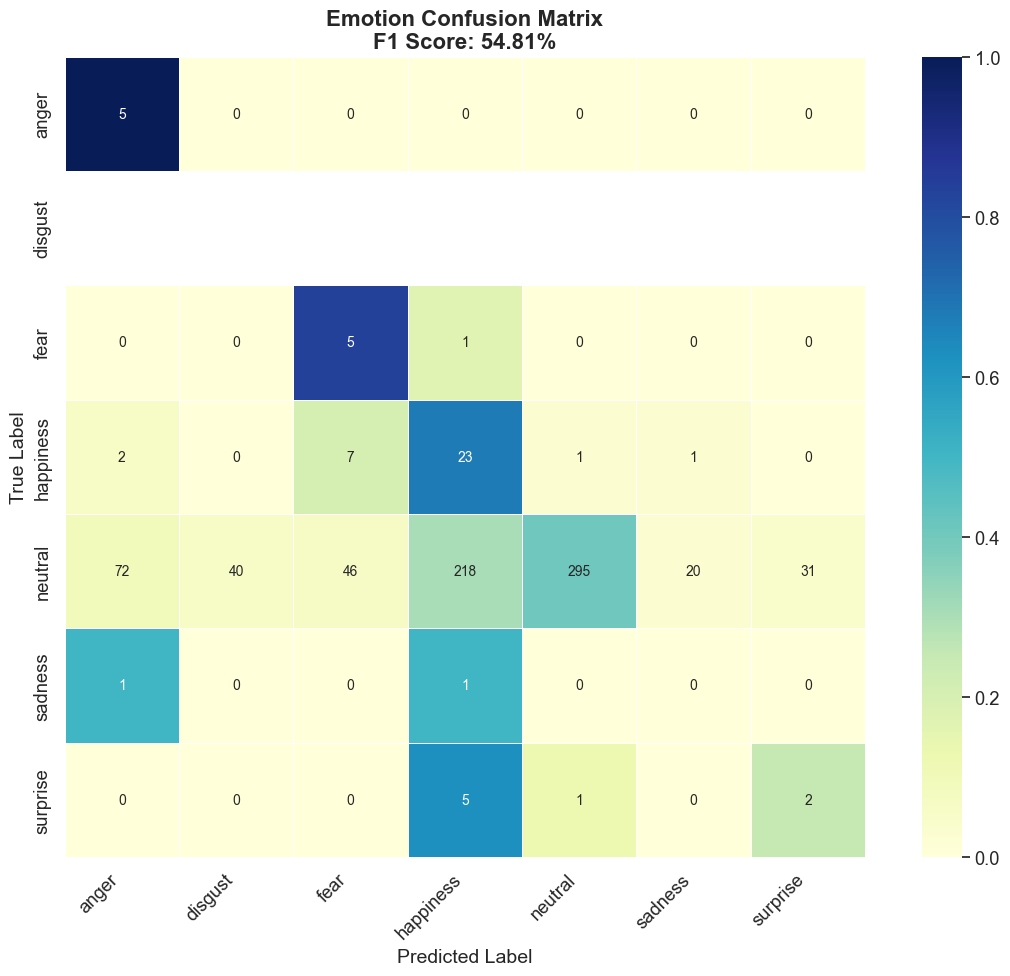

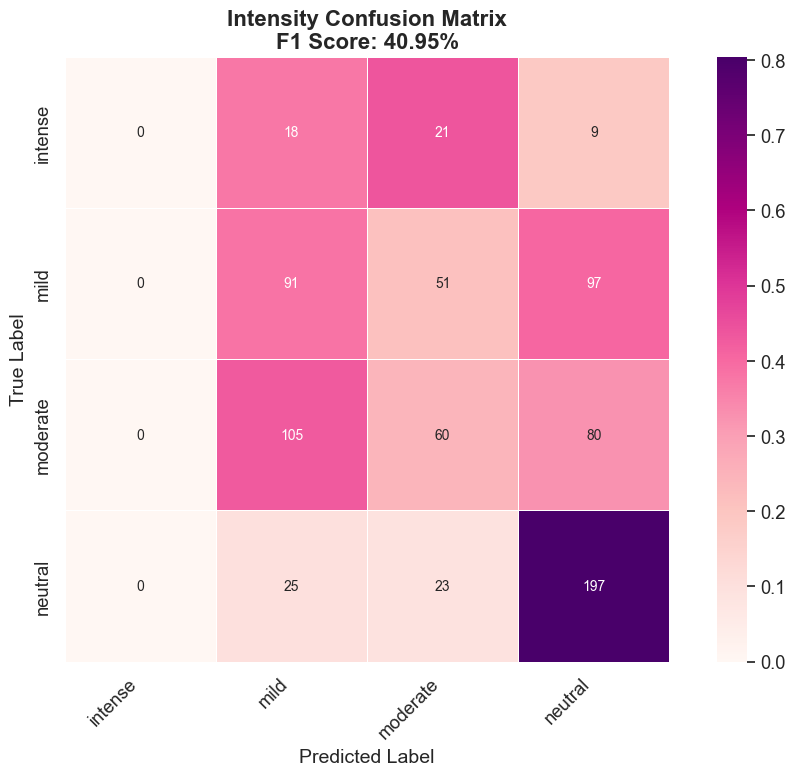

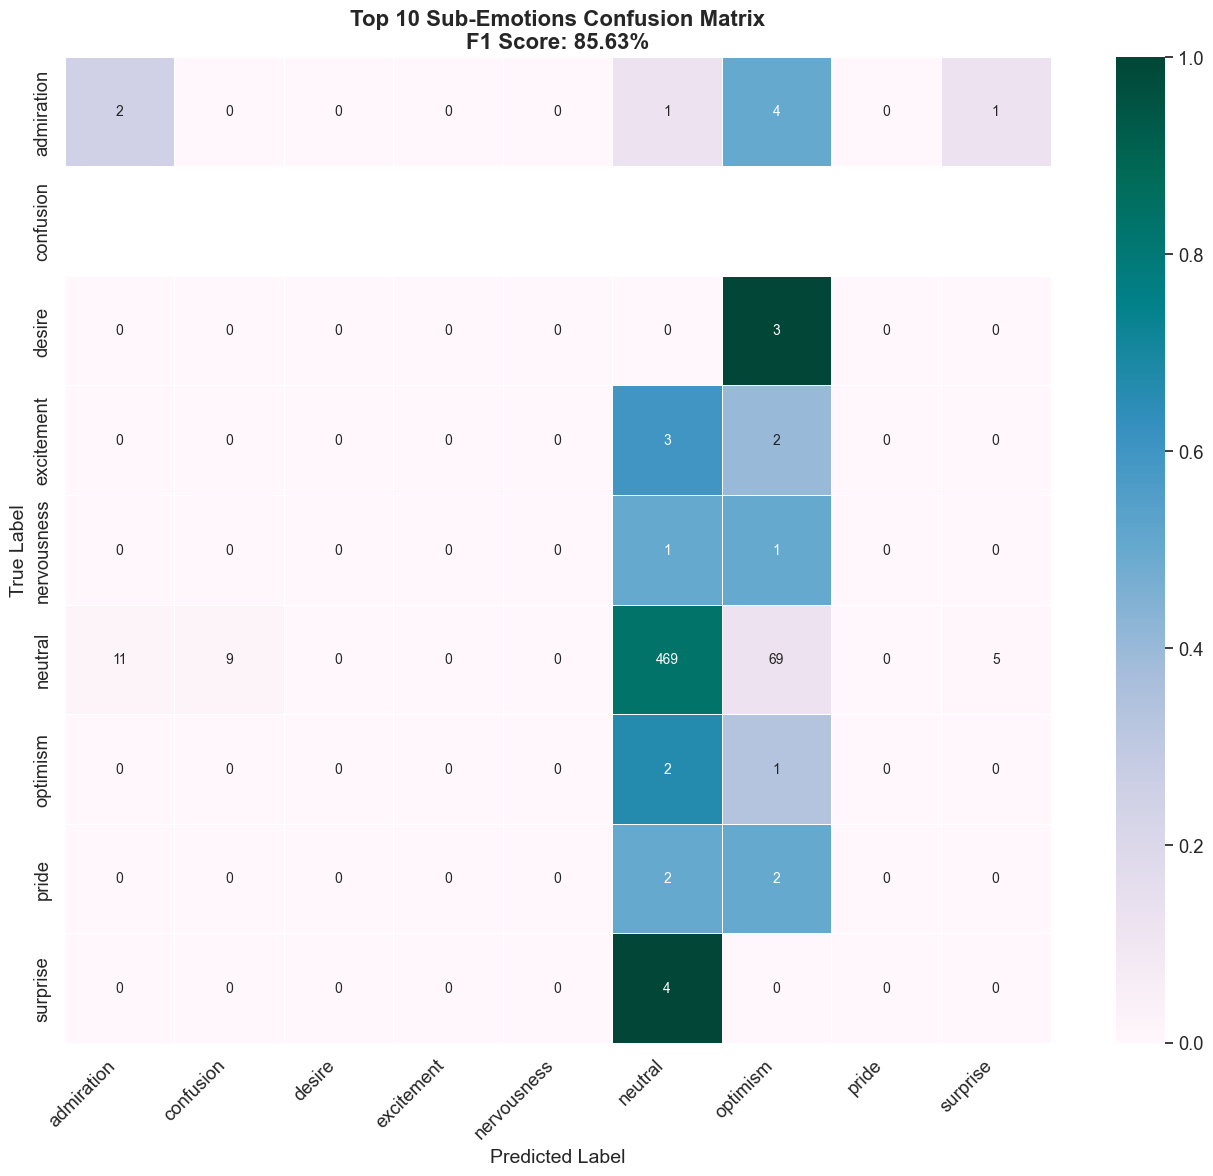

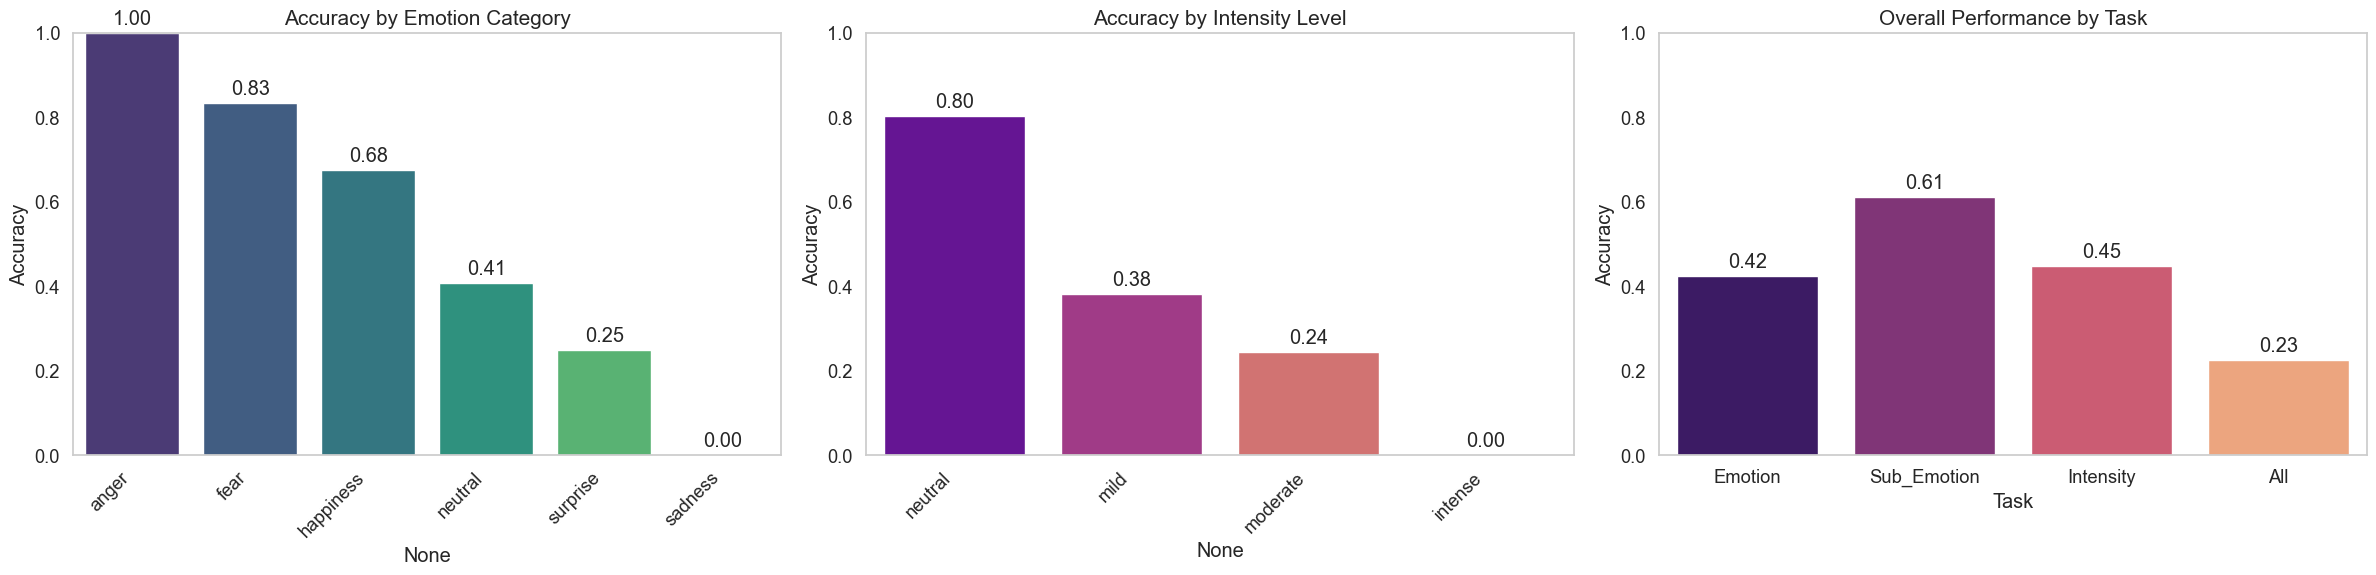


                           MISCLASSIFICATION EXAMPLES                           

Most problematic emotion: neutral
Examples of 'neutral' misclassified:

1. Text: You have a masculinity about you...
   True: neutral → Predicted: disgust
   Sub_emotion: neutral → disapproval
   Intensity: neutral → moderate

2. Text: but don't bring it up too much....
   True: neutral → Predicted: anger
   Sub_emotion: neutral → neutral
   Intensity: neutral → moderate

3. Text: She's not even trying at all....
   True: neutral → Predicted: disgust
   Sub_emotion: neutral → neutral
   Intensity: moderate → neutral

4. Text: When you walk out you have to choose one of the male models to be your co-star as you make your way ...
   True: neutral → Predicted: happiness
   Sub_emotion: neutral → neutral
   Intensity: mild → neutral

5. Text: Please, that's what I want to hear you say....
   True: neutral → Predicted: happiness
   Sub_emotion: neutral → neutral
   Intensity: moderate → neutral


,text,true_emotion,pred_emotion,true_sub_emotion,pred_sub_emotion,true_intensity,pred_intensity,emotion_correct,sub_emotion_correct,intensity_correct,all_correct
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,anger,excitement,annoyance,intense,moderate,False,False,False,False
1,Thousands of model hopefuls from all over Asia...,neutral,happiness,neutral,optimism,moderate,mild,False,False,False,False
2,But only the standout modeling talent were cho...,neutral,happiness,neutral,neutral,moderate,mild,False,True,False,False
3,Prepare for an adventure of a lifetime,happiness,happiness,excitement,optimism,intense,mild,True,False,False,False
4,All I can say girls for this fierce fifth seas...,happiness,happiness,excitement,optimism,moderate,moderate,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
772,Maybe I should have like just shown it at firs...,neutral,fear,neutral,neutral,moderate,moderate,False,True,True,False
773,So even though I'm the first girl to get elimi...,sadness,happiness,disappointment,neutral,moderate,neutral,False,False,False,False
774,Won't give up. I'll stand up after this,neutral,anger,neutral,neutral,intense,moderate,False,True,False,False
775,Next time on Asia's Next Top Model,happiness,happiness,neutral,neutral,neutral,neutral,True,True,True,True


In [37]:
# Evaluate the model
trainer.evaluate_final_model()

Predicting on test set: 100%|██████████| 49/49 [00:03<00:00, 13.18it/s]


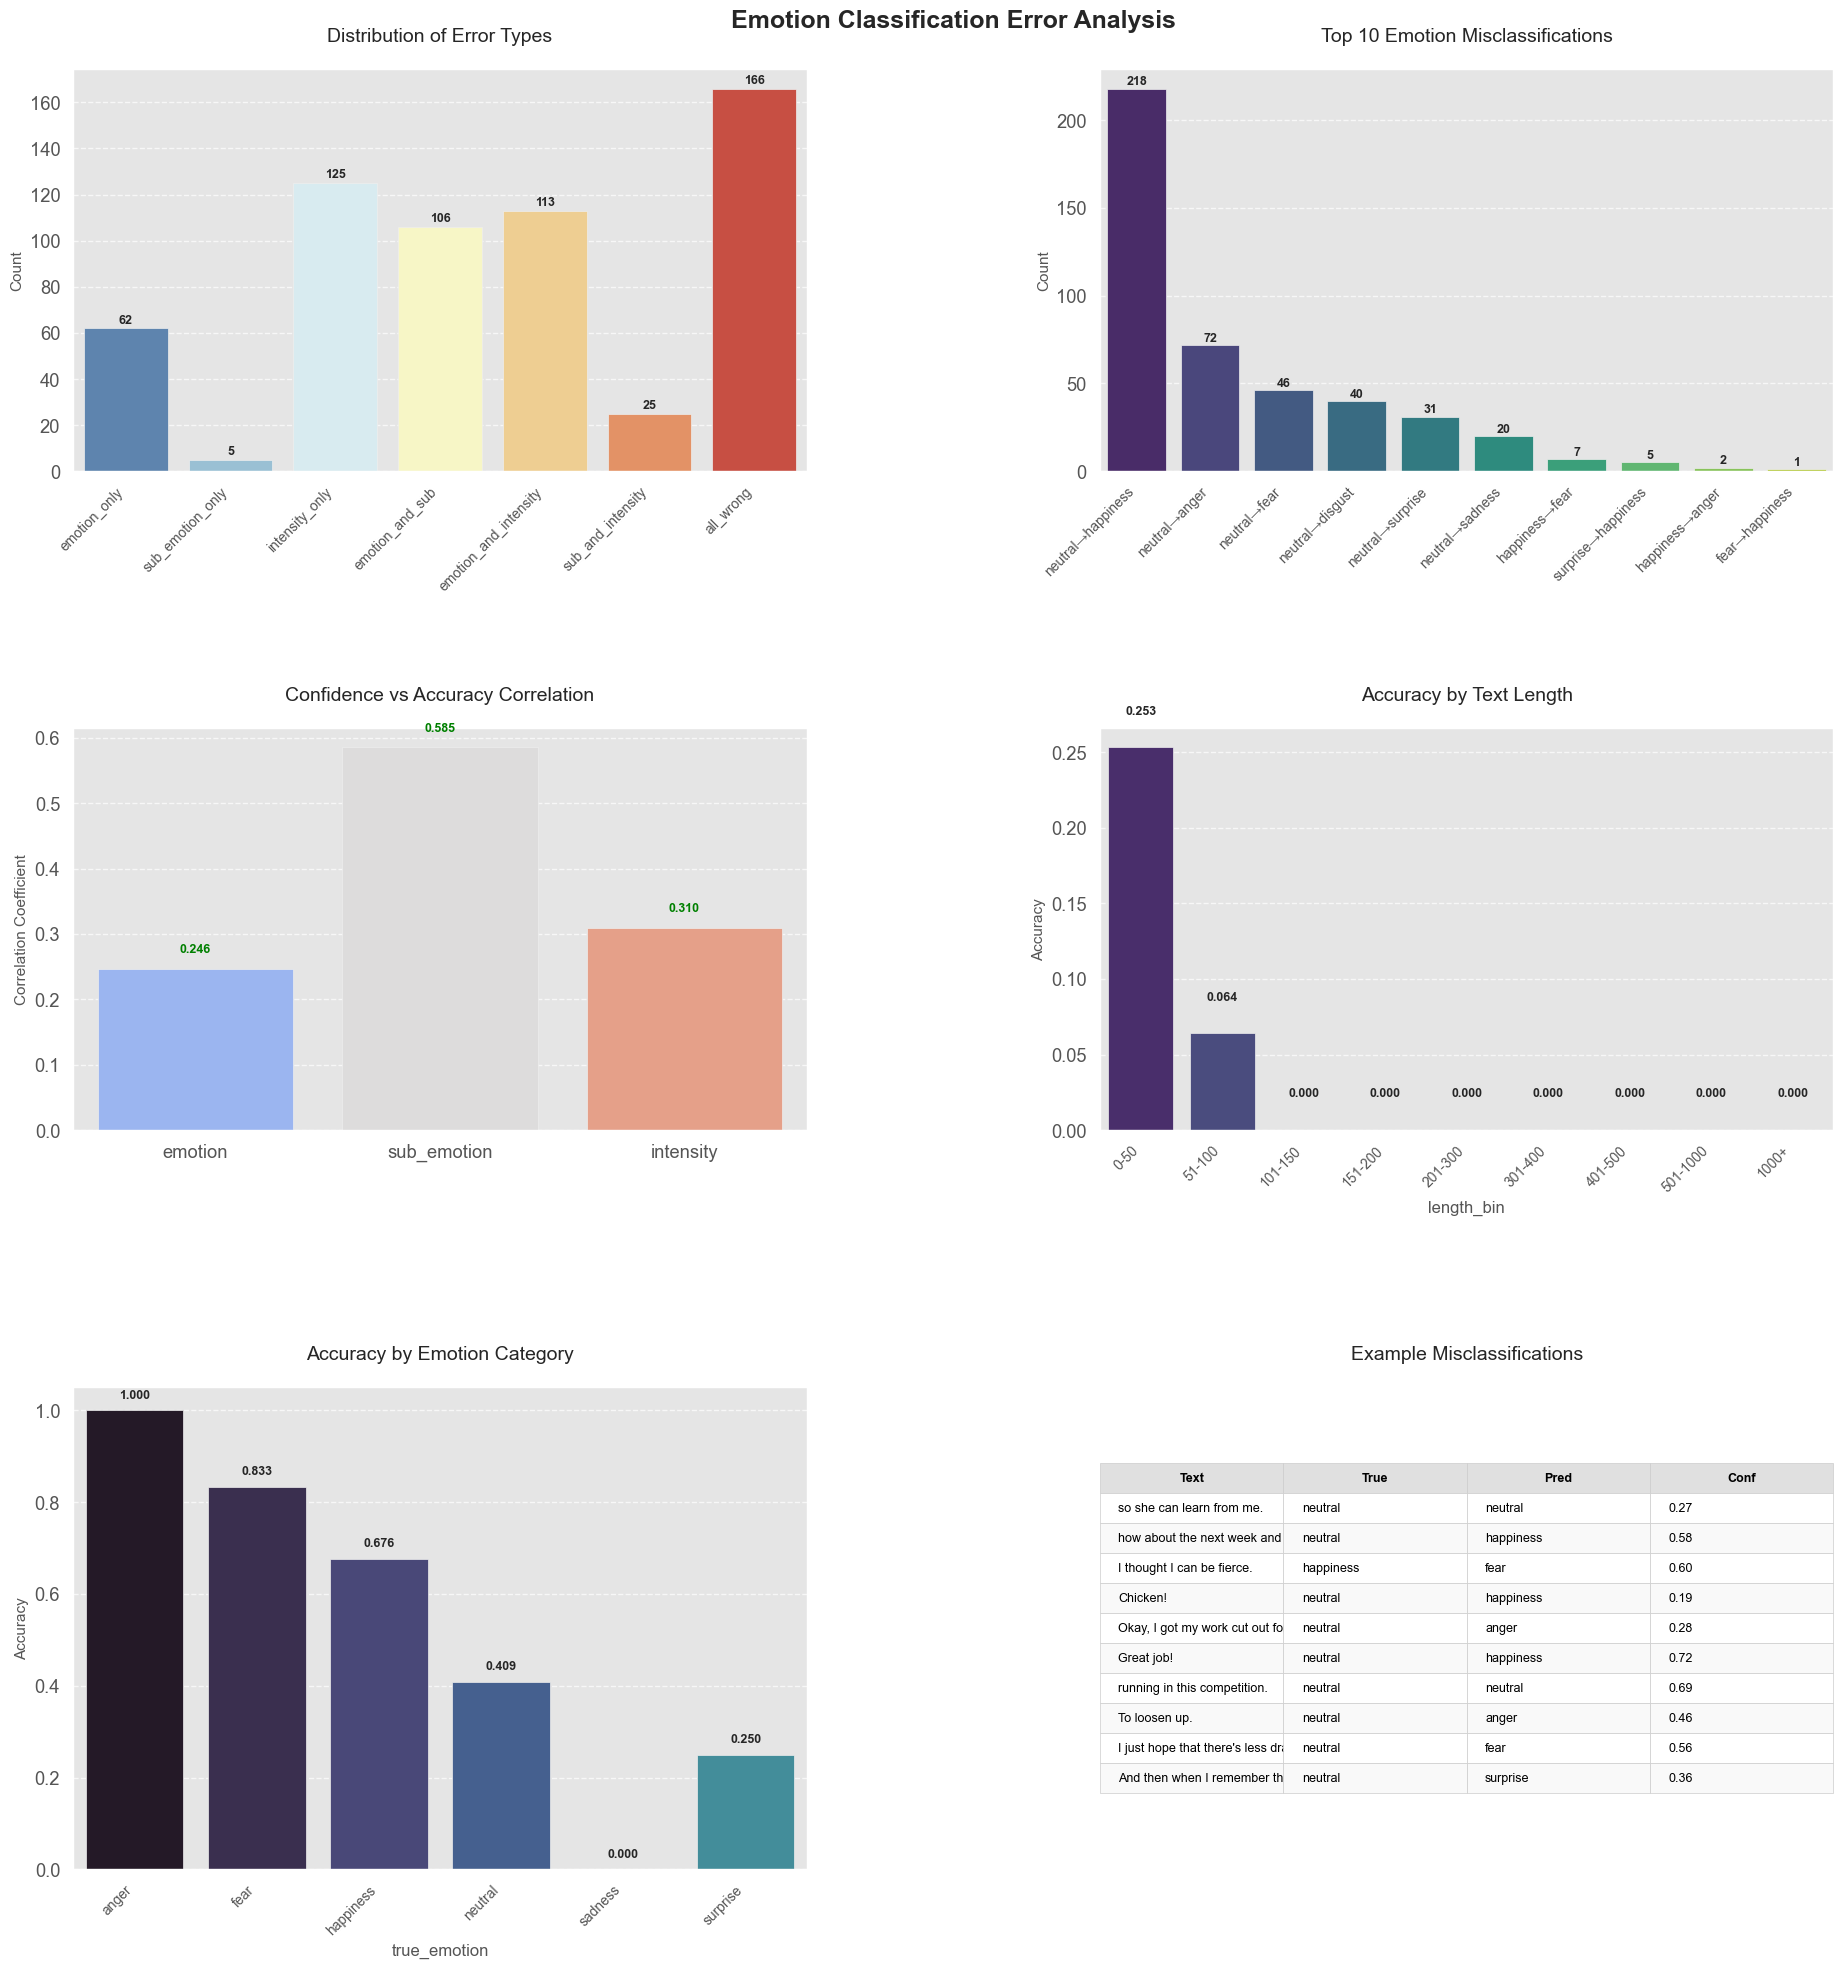


Most common error: true emotion 'neutral' predicted as 'happiness'
Total instances: 218
Average confidence: 0.525

Example 1:
----------------------------------------
Text: Nice, I like that!...
Length: 18 characters
Confidence: 0.729
True emotion: neutral
Predicted: happiness
Sub-emotion: neutral → approval
Intensity: moderate → mild
----------------------------------------

Example 2:
----------------------------------------
Text: Let me hear you say, I want to be here....
Length: 39 characters
Confidence: 0.337
True emotion: neutral
Predicted: happiness
Sub-emotion: neutral → optimism
Intensity: mild → neutral
----------------------------------------

Example 3:
----------------------------------------
Text: That was really cool....
Length: 21 characters
Confidence: 0.703
True emotion: neutral
Predicted: happiness
Sub-emotion: neutral → approval
Intensity: moderate → mild
----------------------------------------

Example 4:
----------------------------------------
Text: Again, so t

In [ ]:
# Error analysis

# Initialize the error analysis with custom configuration
config = AnalysisConfig(
    figure_size=(15, 10),  
    font_size={'title': 14, 'label': 11, 'tick': 9, 'annotation': 9}, 
    color_palette="deep",  
    max_text_length=100,  
    example_count=10,  
    correlation_threshold=0.15,  
    save_plots=True,
    plot_format="png",
    output_dir="./results/error_analysis" 
)

# Initialize the error analyzer
error_analyzer = ErrorAnalysis(
    model=model,
    test_dataloader=test_dataloader,
    device=DEVICE,
    train_df=df,
    test_df=test_df,
    config=config
)

# Run the analysis
results_df, correct_df, error_df = error_analyzer.analyze_errors()
error_analysis = error_analyzer.analyze_error_patterns()

# Visualize results with automatic display in notebook
error_analyzer.visualize_error_patterns()

# Examine specific errors (reduced examples for cleaner notebook output)
error_analyzer.examine_specific_errors(n_examples=5)

# Generate recommendations
recommendations = error_analyzer.generate_recommendations()

# Save results (assuming we're in iteration 1 based on notebook context)
error_analyzer.save_results(iteration_num=ITERATION_NUM)

#### Error Analysis Report

1. **Notable Improvements**:
   - Overall accuracy improved to 0.225 (up from 0.153 in iteration 2)
   - Total errors decreased to 602 (down from 658)
   - Neutral emotion errors reduced to 70.93% (down from 85.11%)

2. **Neutral-Happiness Confusion**:
   - Neutral-to-happiness misclassifications decreased to 218 (from 266)
   - Average confidence increased to 0.525 (up from 0.473), suggesting stronger but not necessarily more accurate predictions
   - Model still struggles with polite expressions and gratitude (e.g., "Thank you," "Nice, I like that!")

3. **Feature Impact**:
   - The addition of EmoLex features appears beneficial, showing improved overall metrics
   - Sub-emotion accuracy improved to 0.611 (from 0.578)
   - Higher confidence correlation for sub-emotions (0.585) suggests better granular emotional understanding

While the EmoLex features have helped improve the model's performance, the persistent neutral-happiness confusion suggests we might need to explore more sophisticated architectural changes or training strategies.


<br>

# Iteration 4

---

After analyzing iterations 2 and 3, we observed that feature engineering approaches didn't significantly improve our model's performance. Returning to our iteration 1 model, we noticed an interesting pattern: while main emotion classification struggles (particularly with neutral-happiness confusion), our sub-emotion classification achieves a promising 74% F1 score on the test set. We'll leverage this insight by implementing post-processing steps that map sub-emotions to their corresponding main emotions, potentially improving our overall classification accuracy without architectural changes.

In [26]:
import transformers
transformers.logging.set_verbosity_error()


In [32]:
# Initialize the model loader
loader = ModelLoader(model_name="bert-base-multilingual-cased")

# Create and load the model
model = loader.load_model(
    feature_dim=0,  # Feature dimension
    num_classes={
        'emotion': 7,      # Number of emotion classes
        'sub_emotion': 28, # Number of sub-emotion classes
        'intensity': 5     # Number of intensity classes
    },
    weights_path="./results/weights/best_test_in_sub_emotion_f1_0.7409_iteration_1.pt"
)

# Create predictor
predictor = loader.create_predictor(model)

# Make predictions
# texts = ["I am so happy today!", "This makes me angry."]
# results = predictor.predict(texts)

Using device: cuda
Loading tokenizer from: bert-base-multilingual-cased
Loading weights from: ./results/weights/best_test_in_sub_emotion_f1_0.7409_iteration_1.pt
Successfully loaded model weights


In [34]:
# Predict the test data
results = predictor.predict(test_df["text"])

# Merge the results with the test data
test_df_preds = pd.merge(test_df, results, on="text")

test_df_preds

Generating predictions: 100%|███████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 12.61it/s]


,text,emotion,sub_emotion,intensity,predicted_emotion,predicted_sub_emotion,predicted_intensity,emotion_pred_post_processed
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,excitement,intense,anger,annoyance,moderate,anger
1,Thousands of model hopefuls from all over Asia...,neutral,neutral,moderate,happiness,optimism,mild,happiness
2,But only the standout modeling talent were cho...,neutral,neutral,moderate,happiness,admiration,mild,happiness
3,Prepare for an adventure of a lifetime,happiness,excitement,intense,happiness,approval,mild,happiness
4,All I can say girls for this fierce fifth seas...,happiness,excitement,moderate,happiness,admiration,mild,happiness
...,...,...,...,...,...,...,...,...
800,Maybe I should have like just shown it at firs...,neutral,neutral,moderate,sadness,neutral,moderate,neutral
801,So even though I'm the first girl to get elimi...,sadness,disappointment,moderate,sadness,neutral,moderate,neutral
802,Won't give up. I'll stand up after this,neutral,neutral,intense,fear,neutral,moderate,neutral
803,Next time on Asia's Next Top Model,happiness,neutral,neutral,happiness,neutral,mild,neutral


In [35]:
# Load the encoder
encoder_path = './results/encoders/emotion_encoder.pkl'
emotion_encoder = joblib.load(encoder_path)

# Get the prediction and true values
pred_vals = test_df_preds["emotion_pred_post_processed"]
true_vals = test_df_preds["emotion"]

# Encode the prediction and true values
encoded_pred_vals = emotion_encoder.transform(pred_vals)
encoded_true_vals = emotion_encoder.transform(true_vals)

# Calculate accuracy, precision, recall, and f1-score
accuracy = accuracy_score(encoded_true_vals, encoded_pred_vals)
precision = precision_score(encoded_true_vals, encoded_pred_vals, average='weighted')
recall = recall_score(encoded_true_vals, encoded_pred_vals, average='weighted')
f1 = f1_score(encoded_true_vals, encoded_pred_vals, average='weighted')

# Calculate loss using nn.CrossEntropyLoss
loss_function = nn.CrossEntropyLoss()
# Convert encoded_pred_vals to a one-hot encoded format
num_classes = len(emotion_encoder.classes_)
model_outputs = torch.tensor(np.eye(num_classes)[encoded_pred_vals], dtype=torch.float32)  # One-hot encoding
true_vals_tensor = torch.tensor(encoded_true_vals, dtype=torch.long)  # Ensure true values are long
loss = loss_function(model_outputs, true_vals_tensor)

# Print the metrics
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Loss: {loss.item():.4f}")

F1 Score: 0.7490
Precision: 0.9057
Recall: 0.6596
Accuracy: 0.6596
Loss: 1.5058


<Figure size 1800x600 with 0 Axes>

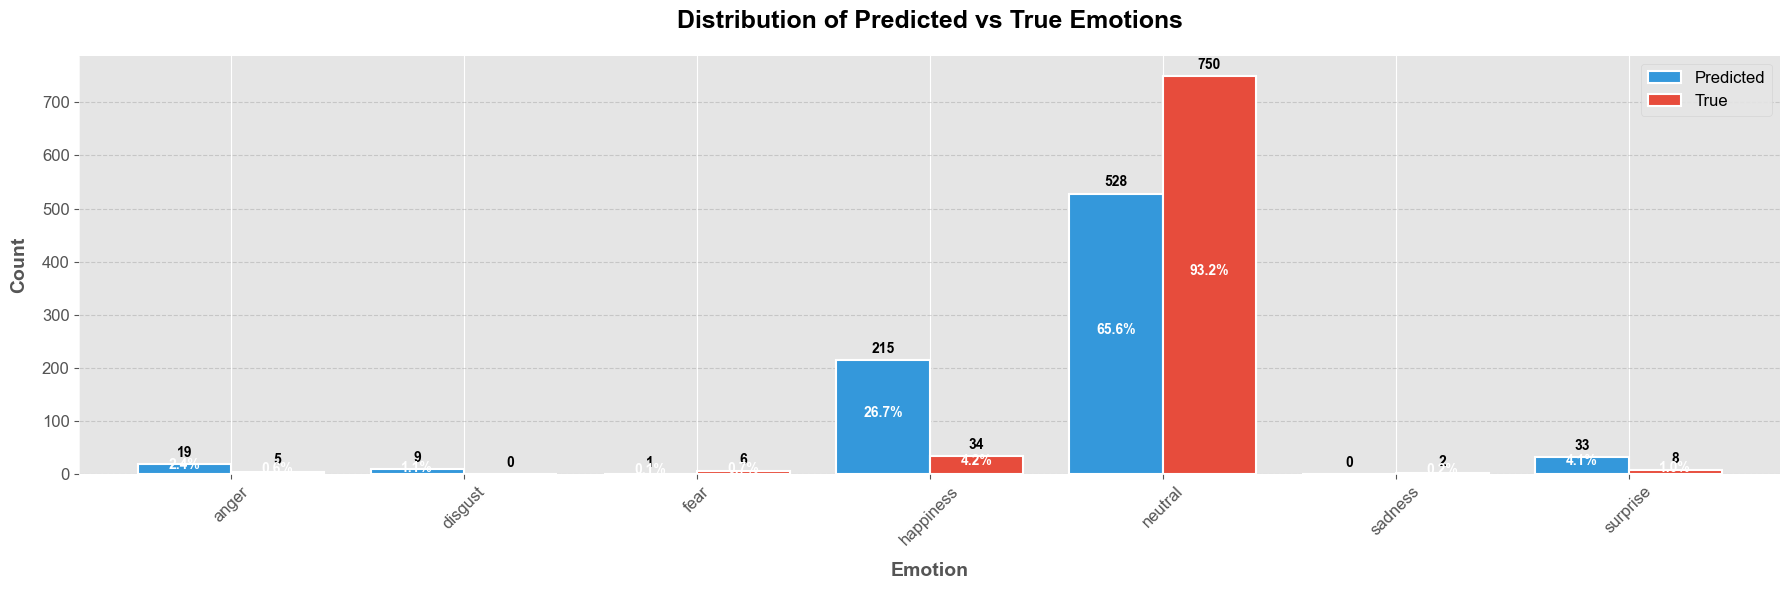

Predicted emotion counts:
  neutral: 528 (65.6%)
  happiness: 215 (26.7%)
  surprise: 33 (4.1%)
  anger: 19 (2.4%)
  disgust: 9 (1.1%)
  fear: 1 (0.1%)

True emotion counts:
  neutral: 750 (93.2%)
  happiness: 34 (4.2%)
  surprise: 8 (1.0%)
  fear: 6 (0.7%)
  anger: 5 (0.6%)
  sadness: 2 (0.2%)


In [36]:
# Get emotion distribution
emotion_counts = test_df_preds["emotion_pred_post_processed"].value_counts()
true_emotion_counts = test_df_preds["emotion"].value_counts()

# Create a figure for a combined chart with a more appealing style
plt.figure(figsize=(18, 6), facecolor='#f9f9f9')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Get all unique emotion categories from both distributions
all_emotions = sorted(set(emotion_counts.index) | set(true_emotion_counts.index))

# Create a DataFrame with both distributions
comparison_df = pd.DataFrame({
    'Predicted': [emotion_counts.get(emotion, 0) for emotion in all_emotions],
    'True': [true_emotion_counts.get(emotion, 0) for emotion in all_emotions]
}, index=all_emotions)

# Plot the combined bar chart with enhanced colors
ax = comparison_df.plot(
    kind='bar', 
    color=['#3498db', '#e74c3c'], 
    figsize=(18, 6),
    width=0.8,
    edgecolor='white',
    linewidth=1.5
)

# Style the chart
ax.set_title('Distribution of Predicted vs True Emotions', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Emotion', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('Count', fontsize=14, fontweight='bold', labelpad=10)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontweight='bold', padding=3, fmt='%d')

# Add percentage labels inside each bar
total_pred = sum(emotion_counts)
total_true = sum(true_emotion_counts)

for i, (emotion, row) in enumerate(comparison_df.iterrows()):
    # Predicted percentage
    if row['Predicted'] > 0:
        percentage = 100 * row['Predicted'] / total_pred
        ax.text(i - 0.2, row['Predicted']/2, f"{percentage:.1f}%", 
                ha='center', color='white', fontweight='bold', fontsize=10)
    
    # True percentage
    if row['True'] > 0:
        percentage = 100 * row['True'] / total_true
        ax.text(i + 0.2, row['True']/2, f"{percentage:.1f}%", 
                ha='center', color='white', fontweight='bold', fontsize=10)

# Add grid and legend with enhanced styling
ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')
ax.legend(['Predicted', 'True'], loc='upper right', fontsize=12, 
          frameon=True, framealpha=0.9, edgecolor='lightgray')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
plt.show()

# Also display the counts as text for reference in a more readable format
print("Predicted emotion counts:")
for emotion, count in emotion_counts.items():
    print(f"  {emotion}: {count} ({100 * count / total_pred:.1f}%)")

print("\nTrue emotion counts:")
for emotion, count in true_emotion_counts.items():
    print(f"  {emotion}: {count} ({100 * count / total_true:.1f}%)")

<br>

# Model Iteration Summary
---

## Overview
This section summarizes our four-iteration journey in developing an emotion classification model, tracking our progression from a baseline BERT implementation through various enhancement attempts, ultimately leading to a significant breakthrough with post-processing techniques.

## Iteration Timeline
| Iteration | Base Model | Features & Modifications | Hypothesis | Best F1 for 'emotion' (Test Set) | Improvement? |
|:---------:|------------|-------------------------|------------|:--------------------------------:|:-------------:|
| 1️⃣ | BERT | - Base BERT embeddings | Basic BERT model will capture emotional context | 0.51 | 📊 Baseline |
| 2️⃣ | BERT | • POS tagging<br>• TextBlob<br>• VADER<br>• TF-IDF | Additional linguistic features will help distinguish neutral from emotional content | 0.49 | ❌ No |
| 3️⃣ | BERT | • All features from Iter 2<br>• EmoLex features | Emotion-specific lexicon will improve emotional understanding | 0.50 | ❌ No* |
| 4️⃣ | BERT | • Base BERT (Iter 1)<br>• Post-processing with sub-emotion mapping | Leveraging strong sub-emotion performance (74% F1) to improve main emotion classification | 0.74 | ✅ Yes |

## Key Findings

### 📈 Performance Evolution
- **Baseline (Iter 1)**: Achieved respectable F1 score of 0.51 with basic BERT
- **Feature Engineering (Iter 2-3)**: Minimal impact despite sophisticated additions
- **Final Breakthrough (Iter 4)**: Significant jump to 0.74 F1 score through strategic post-processing

### 🔍 Error Analysis
- **Persistent Challenge**: Neutral→happiness confusion dominated early iterations
- **Feature Impact**: Engineering reduced misclassifications but at F1 score cost
- **Resolution**: Post-processing strategy effectively addressed core classification issues

### 💡 Critical Insights
1. Complex feature engineering wasn't the answer
2. Leveraging sub-emotion predictions proved most effective
3. Simple, targeted solutions outperformed complex feature additions

*Note: While Iteration 3 showed modest improvements in error patterns and confidence metrics, the F1 score gains were negligible compared to Iteration 2.*

